# Logistics & Supply Chain Data Analysis

# Multivariate Analysis

Domain: Logistics & Supply Chain

Tools Used: Python, Pandas, NumPy, Matplotlib, Seaborn, Jupyter Notebook

# Objective

The objective of this notebook is to analyse the relationships among multiple variables simultaneously to identify hidden patterns, trends and business insights that support data-driven decision-making.

# Import Required Libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

In [5]:
discrepancy_log = pd.read_csv("C:\\My Data _____________________\\Data Analytics\\Project Datasets\\Logistics & Supply Chain – Inventory Management\inventory_discrepancy_log_large.csv")
inventory_item = pd.read_csv("C:\My Data _____________________\Data Analytics\Project Datasets\Logistics & Supply Chain – Inventory Management\inventory_item_master_large.csv")
inventory_kpi = pd.read_csv("C:\My Data _____________________\Data Analytics\Project Datasets\Logistics & Supply Chain – Inventory Management\inventory_kpi_summary_large.csv")
inventory_movement = pd.read_csv("C:\My Data _____________________\Data Analytics\Project Datasets\Logistics & Supply Chain – Inventory Management\inventory_movement_log_large.csv")
inventory_profiling = pd.read_csv("C:\My Data _____________________\Data Analytics\Project Datasets\Logistics & Supply Chain – Inventory Management\inventory_profiling_large.csv")
inventory_validation = pd.read_csv("C:\My Data _____________________\Data Analytics\Project Datasets\Logistics & Supply Chain – Inventory Management\inventory_validation_log_large.csv")
task_allocation = pd.read_csv("C:\\My Data _____________________\\Data Analytics\\Project Datasets\\Logistics & Supply Chain – Inventory Management\\task_allocation_log_large.csv")

# Multivariate Analysis on 'discrepancy_log'

In [6]:
discrepancy_log.groupby(['Warehouse_Code','Discrepancy_Type'])['Variance_Quantity'].sum()

Warehouse_Code  Discrepancy_Type
WH_BLR_01       Count Error         -75
                Damage              -59
                Excess              -42
                Shortage            -60
                Wrong Item         -199
WH_CHN_01       Count Error        -433
                Damage             -325
                Excess             -180
                Shortage           -270
                Wrong Item         -205
WH_DEL_01       Count Error        -141
                Damage             -311
                Excess             -140
                Shortage           -123
                Wrong Item         -251
WH_MUM_01       Count Error         -53
                Damage             -232
                Excess             -370
                Shortage           -236
                Wrong Item           18
WH_NAG_01       Count Error         -89
                Damage             -136
                Excess             -179
                Shortage              8
       

<Axes: xlabel='count', ylabel='Warehouse_Code'>

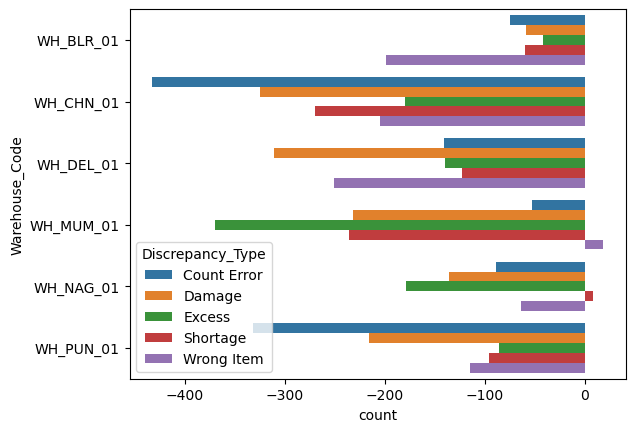

In [7]:
sns.barplot(
    data=discrepancy_log.groupby(['Warehouse_Code',
                                  'Discrepancy_Type'])['Variance_Quantity'].sum().reset_index(name='count'),
    y='Warehouse_Code',
    x='count',
    hue='Discrepancy_Type'
)

In [8]:
dis_var_by_loc = discrepancy_log.groupby(['Warehouse_Code',
                                          'Discrepancy_Type'])['Variance_Quantity'].sum().reset_index(name='count')

In [9]:
dis_var_by_loc[dis_var_by_loc['Discrepancy_Type']=='Count Error']

,Warehouse_Code,Discrepancy_Type,count
0,WH_BLR_01,Count Error,-75
5,WH_CHN_01,Count Error,-433
10,WH_DEL_01,Count Error,-141
15,WH_MUM_01,Count Error,-53
20,WH_NAG_01,Count Error,-89
25,WH_PUN_01,Count Error,-332


In [10]:
dis_var_by_loc[dis_var_by_loc['Discrepancy_Type']=='Excess']

,Warehouse_Code,Discrepancy_Type,count
2,WH_BLR_01,Excess,-42
7,WH_CHN_01,Excess,-180
12,WH_DEL_01,Excess,-140
17,WH_MUM_01,Excess,-370
22,WH_NAG_01,Excess,-179
27,WH_PUN_01,Excess,-86


In [11]:
dis_var_by_loc[dis_var_by_loc['Discrepancy_Type']=='Damage']

,Warehouse_Code,Discrepancy_Type,count
1,WH_BLR_01,Damage,-59
6,WH_CHN_01,Damage,-325
11,WH_DEL_01,Damage,-311
16,WH_MUM_01,Damage,-232
21,WH_NAG_01,Damage,-136
26,WH_PUN_01,Damage,-216


In [12]:
dis_var_by_loc[dis_var_by_loc['Discrepancy_Type']=='Shortage']

,Warehouse_Code,Discrepancy_Type,count
3,WH_BLR_01,Shortage,-60
8,WH_CHN_01,Shortage,-270
13,WH_DEL_01,Shortage,-123
18,WH_MUM_01,Shortage,-236
23,WH_NAG_01,Shortage,8
28,WH_PUN_01,Shortage,-96


In [13]:
discrepancy_log.groupby(['Warehouse_Code',
                         'Root_Cause'])['Variance_Quantity'].sum().reset_index(name='Count')

,Warehouse_Code,Root_Cause,Count
0,WH_BLR_01,Documentation missing,6
1,WH_BLR_01,Handling damage,-380
2,WH_BLR_01,Manual counting error,47
3,WH_BLR_01,System posting delay,-327
4,WH_BLR_01,Vendor short supply,164
5,WH_BLR_01,Wrong bin placement,55
6,WH_CHN_01,Documentation missing,-208
7,WH_CHN_01,Handling damage,-212
8,WH_CHN_01,Manual counting error,-262
9,WH_CHN_01,System posting delay,-237


<Axes: xlabel='Count', ylabel='Warehouse_Code'>

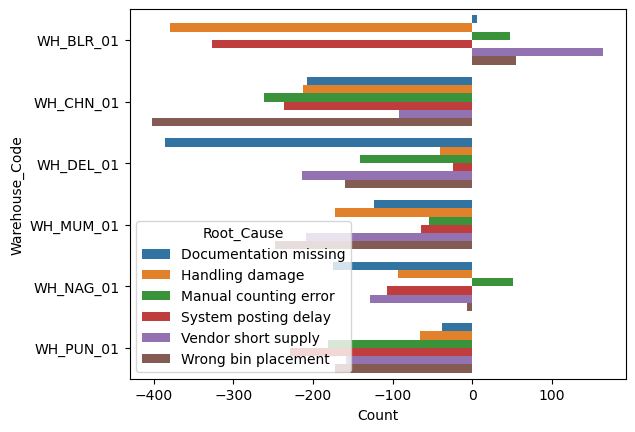

In [14]:
sns.barplot (
    data = discrepancy_log.groupby(['Warehouse_Code',
                         'Root_Cause'])['Variance_Quantity'].sum().reset_index(name='Count'),
            x='Count', y= 'Warehouse_Code', hue='Root_Cause'
)

In [15]:
root_var_by_loc = discrepancy_log.groupby(['Warehouse_Code',
                         'Root_Cause'])['Variance_Quantity'].sum().reset_index(name='Count')

In [16]:
discrepancy_log['Root_Cause'].unique()

array(['Documentation missing', 'Handling damage', 'Vendor short supply',
       'System posting delay', 'Wrong bin placement',
       'Manual counting error'], dtype=object)

In [17]:
root_var_by_loc[root_var_by_loc['Root_Cause']=='Wrong bin placement']

,Warehouse_Code,Root_Cause,Count
5,WH_BLR_01,Wrong bin placement,55
11,WH_CHN_01,Wrong bin placement,-402
17,WH_DEL_01,Wrong bin placement,-160
23,WH_MUM_01,Wrong bin placement,-248
29,WH_NAG_01,Wrong bin placement,-7
35,WH_PUN_01,Wrong bin placement,-173


In [18]:
root_var_by_loc[root_var_by_loc['Root_Cause']=='Documentation missing']

,Warehouse_Code,Root_Cause,Count
0,WH_BLR_01,Documentation missing,6
6,WH_CHN_01,Documentation missing,-208
12,WH_DEL_01,Documentation missing,-386
18,WH_MUM_01,Documentation missing,-124
24,WH_NAG_01,Documentation missing,-175
30,WH_PUN_01,Documentation missing,-38


In [19]:
root_var_by_loc[root_var_by_loc['Root_Cause']=='Handling damage']

,Warehouse_Code,Root_Cause,Count
1,WH_BLR_01,Handling damage,-380
7,WH_CHN_01,Handling damage,-212
13,WH_DEL_01,Handling damage,-41
19,WH_MUM_01,Handling damage,-173
25,WH_NAG_01,Handling damage,-93
31,WH_PUN_01,Handling damage,-66


In [20]:
root_var_by_loc[root_var_by_loc['Root_Cause']=='Vendor short supply']

,Warehouse_Code,Root_Cause,Count
4,WH_BLR_01,Vendor short supply,164
10,WH_CHN_01,Vendor short supply,-92
16,WH_DEL_01,Vendor short supply,-214
22,WH_MUM_01,Vendor short supply,-209
28,WH_NAG_01,Vendor short supply,-129
34,WH_PUN_01,Vendor short supply,-158


In [21]:
root_var_by_loc[root_var_by_loc['Root_Cause']=='System posting delay']

,Warehouse_Code,Root_Cause,Count
3,WH_BLR_01,System posting delay,-327
9,WH_CHN_01,System posting delay,-237
15,WH_DEL_01,System posting delay,-24
21,WH_MUM_01,System posting delay,-64
27,WH_NAG_01,System posting delay,-107
33,WH_PUN_01,System posting delay,-229


In [22]:
root_var_by_loc[root_var_by_loc['Root_Cause']=='Manual counting error']

,Warehouse_Code,Root_Cause,Count
2,WH_BLR_01,Manual counting error,47
8,WH_CHN_01,Manual counting error,-262
14,WH_DEL_01,Manual counting error,-141
20,WH_MUM_01,Manual counting error,-55
26,WH_NAG_01,Manual counting error,51
32,WH_PUN_01,Manual counting error,-181


In [23]:
discrepancy_log.groupby(['Warehouse_Code',
                         'Resolution_Status'])['Variance_Quantity'].sum().reset_index(name='Count')

,Warehouse_Code,Resolution_Status,Count
0,WH_BLR_01,Adjusted,-30
1,WH_BLR_01,Open,-165
2,WH_BLR_01,Resolved,-344
3,WH_BLR_01,Under Investigation,104
4,WH_CHN_01,Adjusted,-459
5,WH_CHN_01,Open,-282
6,WH_CHN_01,Resolved,-380
7,WH_CHN_01,Under Investigation,-292
8,WH_DEL_01,Adjusted,-216
9,WH_DEL_01,Open,-297


<Axes: xlabel='Count', ylabel='Warehouse_Code'>

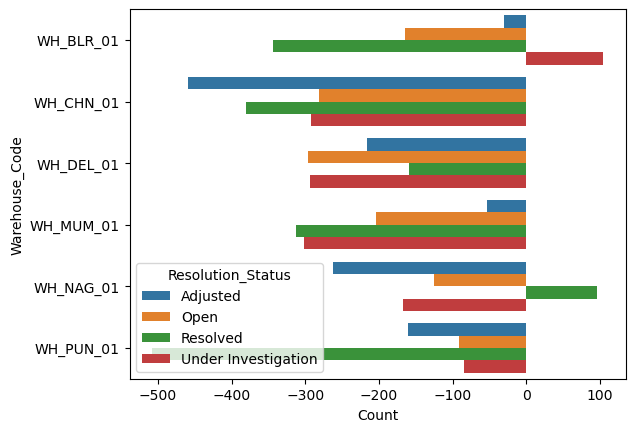

In [24]:
sns.barplot(
    data = discrepancy_log.groupby(['Warehouse_Code',
                         'Resolution_Status'])['Variance_Quantity'].sum().reset_index(name='Count'),
    x = 'Count',
    y = 'Warehouse_Code',
    hue = 'Resolution_Status'
)

In [25]:
status_var_by_loc = discrepancy_log.groupby(['Warehouse_Code',
                         'Resolution_Status'])['Variance_Quantity'].sum().reset_index(name='Count')

In [26]:
status_var_by_loc['Resolution_Status'].unique()

array(['Adjusted', 'Open', 'Resolved', 'Under Investigation'],
      dtype=object)

In [27]:
status_var_by_loc[status_var_by_loc['Resolution_Status']=='Resolved']

,Warehouse_Code,Resolution_Status,Count
2,WH_BLR_01,Resolved,-344
6,WH_CHN_01,Resolved,-380
10,WH_DEL_01,Resolved,-159
14,WH_MUM_01,Resolved,-313
18,WH_NAG_01,Resolved,96
22,WH_PUN_01,Resolved,-508


In [28]:
status_var_by_loc[status_var_by_loc['Resolution_Status']=='Open']

,Warehouse_Code,Resolution_Status,Count
1,WH_BLR_01,Open,-165
5,WH_CHN_01,Open,-282
9,WH_DEL_01,Open,-297
13,WH_MUM_01,Open,-204
17,WH_NAG_01,Open,-126
21,WH_PUN_01,Open,-91


In [29]:
status_var_by_loc[status_var_by_loc['Resolution_Status']=='Under Investigation']

,Warehouse_Code,Resolution_Status,Count
3,WH_BLR_01,Under Investigation,104
7,WH_CHN_01,Under Investigation,-292
11,WH_DEL_01,Under Investigation,-294
15,WH_MUM_01,Under Investigation,-302
19,WH_NAG_01,Under Investigation,-167
23,WH_PUN_01,Under Investigation,-85


In [30]:
status_var_by_loc[status_var_by_loc['Resolution_Status']=='Adjusted']

,Warehouse_Code,Resolution_Status,Count
0,WH_BLR_01,Adjusted,-30
4,WH_CHN_01,Adjusted,-459
8,WH_DEL_01,Adjusted,-216
12,WH_MUM_01,Adjusted,-54
16,WH_NAG_01,Adjusted,-263
20,WH_PUN_01,Adjusted,-161


# Multivariate Analysis on 'inventory_item'

In [31]:
inventory_item.head(2)

,Item_ID,Item_Description,Item_Category,Priority_Level,UOM,Warehouse_Code,Warehouse_City,Active_Flag
0,ITEM100000,Inventory Item 1,Packaging,Low,Kg,WH_BLR_01,Bangalore,Yes
1,ITEM100001,Inventory Item 2,Packaging,Medium,Pallet,WH_MUM_01,Mumbai,No


In [32]:
inventory_item.shape

(40000, 8)

In [33]:
a = inventory_item[(inventory_item['Priority_Level']=='High') & (inventory_item['Active_Flag']=='Yes')] 

In [34]:
a.head(5)

,Item_ID,Item_Description,Item_Category,Priority_Level,UOM,Warehouse_Code,Warehouse_City,Active_Flag
3,ITEM100003,Inventory Item 4,Raw Material,High,Kg,WH_CHN_01,Chennai,Yes
5,ITEM100005,Inventory Item 6,Raw Material,High,Pallet,WH_DEL_01,Delhi,Yes
20,ITEM100020,Inventory Item 21,Finished Goods,High,Nos,WH_MUM_01,Mumbai,Yes
24,ITEM100024,Inventory Item 25,Finished Goods,High,Box,WH_MUM_01,Mumbai,Yes
28,ITEM100028,Inventory Item 29,Raw Material,High,Box,WH_NAG_01,Nagpur,Yes


In [35]:
pd.crosstab(a['Item_Category'],a['Warehouse_City'])

Warehouse_City,Bangalore,Chennai,Delhi,Mumbai,Nagpur,Pune
Item_Category,,,,,,
Consumables,152,174,151,151,145,147
Finished Goods,502,467,486,464,474,433
Packaging,264,265,277,309,244,271
Raw Material,385,426,415,406,430,429
Spare Parts,161,183,191,187,174,188


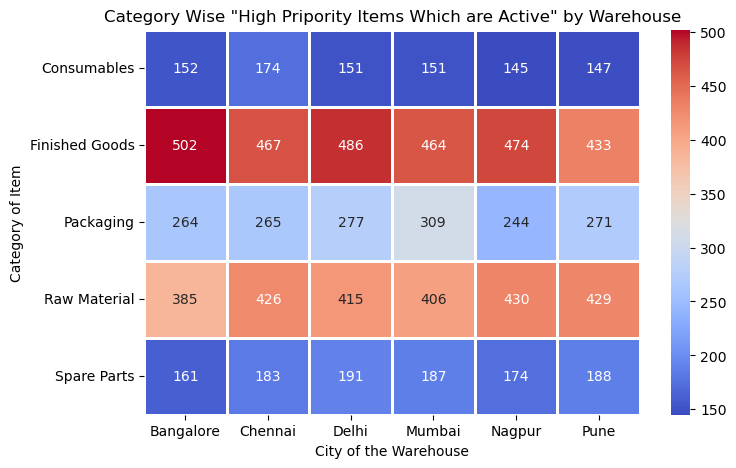

In [36]:
plt.figure(figsize=(8,5))
sns.heatmap(pd.crosstab(a['Item_Category'],a['Warehouse_City']), 
            annot=True, 
            fmt="d",   # remove decimals if not needed
            cmap='coolwarm',
            linewidths=0.9)

plt.title('Category Wise "High Pripority Items Which are Active" by Warehouse')
plt.ylabel('Category of Item')
plt.xlabel('City of the Warehouse')

plt.show()

In [37]:
inventory_item[(inventory_item['Priority_Level']=='Low') & (inventory_item['Active_Flag']=='Yes')] 

,Item_ID,Item_Description,Item_Category,Priority_Level,UOM,Warehouse_Code,Warehouse_City,Active_Flag
0,ITEM100000,Inventory Item 1,Packaging,Low,Kg,WH_BLR_01,Bangalore,Yes
6,ITEM100006,Inventory Item 7,Finished Goods,Low,Kg,WH_CHN_01,Chennai,Yes
9,ITEM100009,Inventory Item 10,Packaging,Low,Box,WH_NAG_01,Nagpur,Yes
10,ITEM100010,Inventory Item 11,Raw Material,Low,Box,WH_NAG_01,Nagpur,Yes
11,ITEM100011,Inventory Item 12,Finished Goods,Low,Pallet,WH_NAG_01,Nagpur,Yes
...,...,...,...,...,...,...,...,...
39968,ITEM139968,Inventory Item 39969,Finished Goods,Low,Kg,WH_PUN_01,Pune,Yes
39978,ITEM139978,Inventory Item 39979,Finished Goods,Low,Box,WH_DEL_01,Delhi,Yes
39981,ITEM139981,Inventory Item 39982,Finished Goods,Low,Kg,WH_CHN_01,Chennai,Yes
39994,ITEM139994,Inventory Item 39995,Raw Material,Low,Nos,WH_PUN_01,Pune,Yes


In [38]:
inventory_item['Item_Category'].unique()

array(['Packaging', 'Finished Goods', 'Raw Material', 'Consumables',
       'Spare Parts'], dtype=object)

In [39]:
b = inventory_item[(inventory_item['Item_Category']=='Finished Goods') & 
    (inventory_item['Active_Flag']=='Yes')]

In [40]:
pd.crosstab(b['Warehouse_City'],b['Priority_Level'])

Priority_Level,High,Low,Medium
Warehouse_City,,,
Bangalore,502,403,742
Chennai,467,362,674
Delhi,486,414,743
Mumbai,464,396,697
Nagpur,474,395,794
Pune,433,393,707


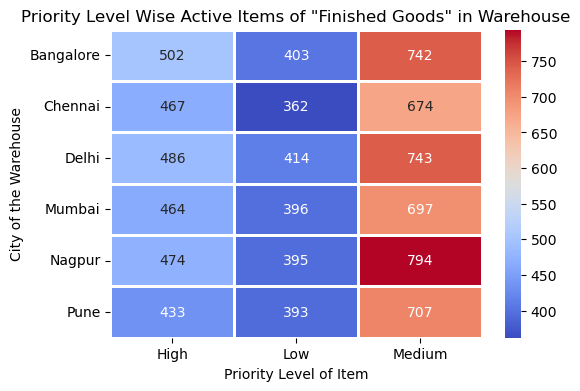

In [41]:
plt.figure(figsize=(6,4))
sns.heatmap(pd.crosstab(b['Warehouse_City'],b['Priority_Level']), 
            annot=True, 
            fmt="d",   # remove decimals if not needed
            cmap='coolwarm',
            linewidths=0.9)

plt.title('Priority Level Wise Active Items of "Finished Goods" in Warehouse')
plt.ylabel('City of the Warehouse')
plt.xlabel('Priority Level of Item')

plt.show()

# Multivariate Analysis on 'inventory_kpi'

In [42]:
inventory_kpi.head(2)

,Year_Month,Warehouse_Code,Tasks_Assigned,Tasks_Completed,Avg_Assigned_Qty,Total_Movements,Inward_Movements,Outward_Movements,Total_Quantity_Moved,Mismatch_Count,Discrepancy_Count,Total_Variance,Validations_Done,Validation_Failures,Task_Completion_Rate_%,Mismatch_Rate_%,Validation_Failure_Rate_%
0,2021-01,WH_BLR_01,319,273,20.605016,437,216,221,8580,47,58,-61,407,86,85.58,10.76,21.13
1,2021-01,WH_CHN_01,350,294,20.985714,408,193,215,7756,42,52,-41,407,86,84.00,10.29,21.13


In [43]:
inventory_kpi.groupby('Warehouse_Code')['Tasks_Assigned'].agg(['min','mean','max'])

,min,mean,max
Warehouse_Code,,,
WH_BLR_01,288,350.437500,397
WH_CHN_01,294,346.479167,384
WH_DEL_01,292,346.229167,383
WH_MUM_01,282,348.041667,405
WH_NAG_01,315,350.541667,394
WH_PUN_01,285,341.604167,387


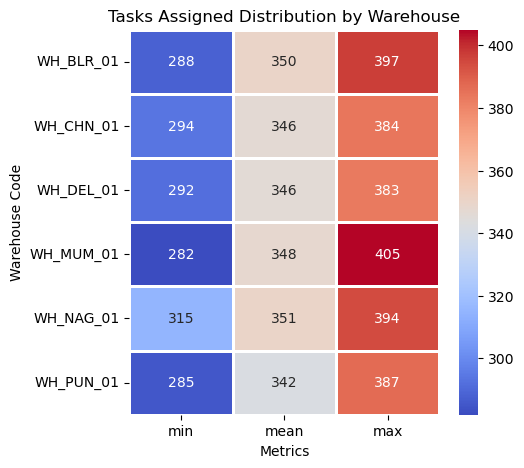

In [44]:
plt.figure(figsize=(5,5))
sns.heatmap(inventory_kpi.groupby('Warehouse_Code')['Tasks_Assigned'].agg(['min','mean','max']), 
            annot=True, 
            fmt=".0f",   # remove decimals if not needed
            cmap='coolwarm',
            linewidths=0.9)

plt.title('Tasks Assigned Distribution by Warehouse')
plt.ylabel('Warehouse Code')
plt.xlabel('Metrics')

plt.show()

In [45]:
inventory_kpi.groupby('Warehouse_Code')['Tasks_Completed'].agg(['min','mean','max'])

,min,mean,max
Warehouse_Code,,,
WH_BLR_01,251,295.958333,340
WH_CHN_01,242,294.687500,329
WH_DEL_01,250,293.666667,323
WH_MUM_01,242,295.437500,343
WH_NAG_01,259,298.125000,347
WH_PUN_01,236,290.812500,334


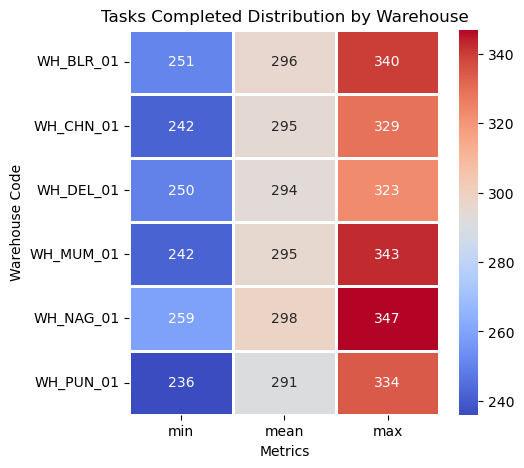

In [46]:
plt.figure(figsize=(5,5))
sns.heatmap(inventory_kpi.groupby('Warehouse_Code')['Tasks_Completed'].agg(['min','mean','max']), 
            annot=True, 
            fmt=".0f",   # remove decimals if not needed
            cmap='coolwarm',
            linewidths=0.9)

plt.title('Tasks Completed Distribution by Warehouse')
plt.ylabel('Warehouse Code')
plt.xlabel('Metrics')

plt.show()

In [47]:
inventory_kpi['Tasks_Assigned'].agg(['min','mean','max'])

min     282.000000
mean    347.222222
max     405.000000
Name: Tasks_Assigned, dtype: float64

In [48]:
inventory_kpi['Tasks_Completed'].agg(['min','mean','max'])

min     236.00000
mean    294.78125
max     347.00000
Name: Tasks_Completed, dtype: float64

In [49]:
c = inventory_kpi[(inventory_kpi['Tasks_Assigned'] > 347) & 
    (inventory_kpi['Tasks_Completed'] > 295)] 

In [50]:
c

,Year_Month,Warehouse_Code,Tasks_Assigned,Tasks_Completed,Avg_Assigned_Qty,Total_Movements,Inward_Movements,Outward_Movements,Total_Quantity_Moved,Mismatch_Count,Discrepancy_Count,Total_Variance,Validations_Done,Validation_Failures,Task_Completion_Rate_%,Mismatch_Rate_%,Validation_Failure_Rate_%
2,2021-01,WH_DEL_01,350,306,20.468571,451,232,219,8565,44,56,-35,407,86,87.43,9.76,21.13
3,2021-01,WH_MUM_01,354,298,20.629944,410,193,217,8087,34,46,-32,407,86,84.18,8.29,21.13
4,2021-01,WH_NAG_01,364,308,19.164835,429,213,216,8417,41,53,19,407,86,84.62,9.56,21.13
5,2021-01,WH_PUN_01,379,329,20.158311,430,195,235,7854,35,50,-53,407,86,86.81,8.14,21.13
12,2021-03,WH_BLR_01,367,311,19.863760,432,208,224,8593,40,48,-26,467,99,84.74,9.26,21.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,2024-10,WH_NAG_01,371,318,19.851752,448,215,233,8064,50,59,59,403,87,85.71,11.16,21.59
282,2024-12,WH_BLR_01,390,324,20.602564,432,189,243,8235,45,53,39,428,109,83.08,10.42,25.47
283,2024-12,WH_CHN_01,360,307,20.719444,418,209,209,8104,38,50,-114,428,109,85.28,9.09,25.47
284,2024-12,WH_DEL_01,357,307,20.243697,446,223,223,8417,52,63,-12,428,109,85.99,11.66,25.47


In [51]:
c.groupby('Warehouse_Code')['Tasks_Assigned'].sum().reset_index(name='count')

,Warehouse_Code,count
0,WH_BLR_01,9205
1,WH_CHN_01,7608
2,WH_DEL_01,7980
3,WH_MUM_01,7688
4,WH_NAG_01,8788
5,WH_PUN_01,6517


<Axes: xlabel='Tasks_Assigned', ylabel='Warehouse_Code'>

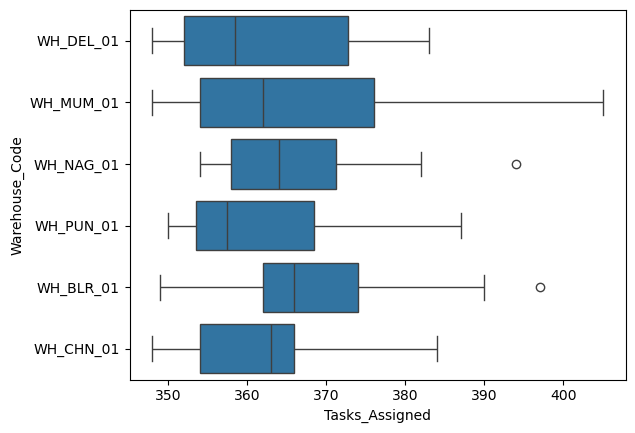

In [52]:
sns.boxplot(data=c, x='Tasks_Assigned', y='Warehouse_Code')

In [53]:
c.groupby('Warehouse_Code')['Tasks_Completed'].sum().reset_index(name='count')

,Warehouse_Code,count
0,WH_BLR_01,7772
1,WH_CHN_01,6508
2,WH_DEL_01,6814
3,WH_MUM_01,6560
4,WH_NAG_01,7566
5,WH_PUN_01,5592


<Axes: xlabel='Tasks_Completed', ylabel='Warehouse_Code'>

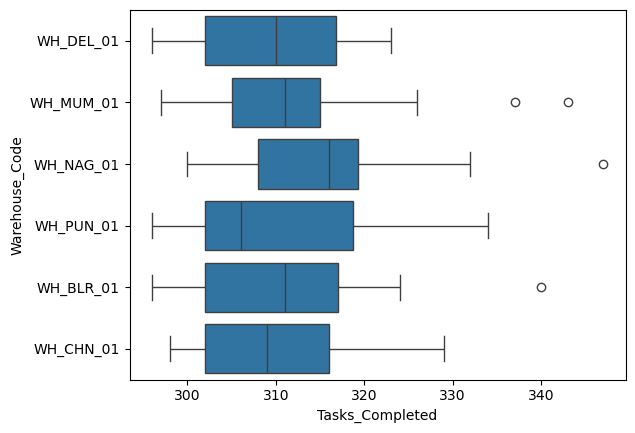

In [54]:
sns.boxplot(data=c, x='Tasks_Completed', y='Warehouse_Code')

In [55]:
inventory_kpi['Task_Completion_Rate_%'].mean()

np.float64(84.88951388888889)

In [56]:
inventory_kpi.groupby('Warehouse_Code')['Task_Completion_Rate_%'].mean()

Warehouse_Code
WH_BLR_01    84.476042
WH_CHN_01    85.042083
WH_DEL_01    84.825208
WH_MUM_01    84.884583
WH_NAG_01    85.002708
WH_PUN_01    85.106458
Name: Task_Completion_Rate_%, dtype: float64

inventory_kpi.groupby('Warehouse_Code')['Mismatch_Rate_%'].mean()

In [57]:
inventory_kpi.groupby('Warehouse_Code')['Validation_Failure_Rate_%'].mean()

Warehouse_Code
WH_BLR_01    21.885417
WH_CHN_01    21.885417
WH_DEL_01    21.885417
WH_MUM_01    21.885417
WH_NAG_01    21.885417
WH_PUN_01    21.885417
Name: Validation_Failure_Rate_%, dtype: float64

# Multivariate Analysis on 'inventory_movement'

In [58]:
inventory_movement.head(3)

,Movement_ID,Movement_Date,Item_ID,Warehouse_Code,Task_ID,Movement_Type,Movement_Quantity,Source,Destination,Verification_Status
0,MOV3000000,2021-10-24,ITEM127431,WH_DEL_01,TASK2054000,Inward,17,Return,Plant,Verified
1,MOV3000001,2024-03-09,ITEM138426,WH_CHN_01,TASK2039625,Inward,9,Plant,Customer,Verified
2,MOV3000002,2024-11-29,ITEM106984,WH_PUN_01,TASK2097842,Outward,15,Return,Customer,Verified


In [59]:
inventory_movement.groupby(['Warehouse_Code','Movement_Type'])['Movement_Quantity'].mean()

Warehouse_Code  Movement_Type
WH_BLR_01       Inward           19.530371
                Outward          19.450917
WH_CHN_01       Inward           19.801875
                Outward          19.686031
WH_DEL_01       Inward           19.638683
                Outward          19.675423
WH_MUM_01       Inward           19.780290
                Outward          19.604037
WH_NAG_01       Inward           19.246561
                Outward          19.478830
WH_PUN_01       Inward           19.837964
                Outward          19.625730
Name: Movement_Quantity, dtype: float64

In [60]:
inventory_movement.groupby(
    ['Warehouse_Code','Movement_Type'])['Verification_Status'].size().reset_index(name='count')

,Warehouse_Code,Movement_Type,count
0,WH_BLR_01,Inward,9812
1,WH_BLR_01,Outward,10523
2,WH_CHN_01,Inward,9494
3,WH_CHN_01,Outward,10294
4,WH_DEL_01,Inward,9601
5,WH_DEL_01,Outward,10392
6,WH_MUM_01,Inward,9599
7,WH_MUM_01,Outward,10453
8,WH_NAG_01,Inward,9742
9,WH_NAG_01,Outward,10392


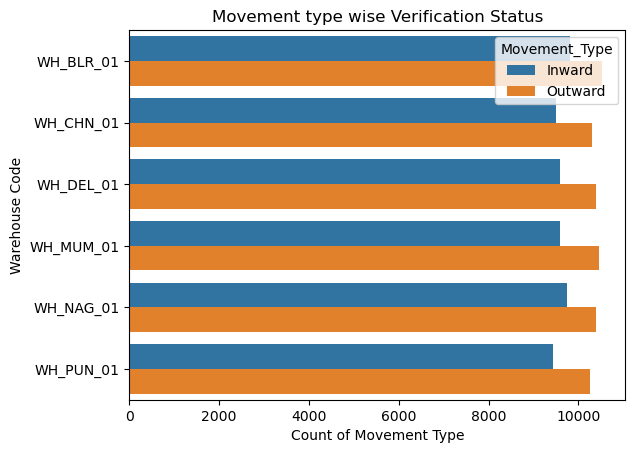

In [61]:
sns.barplot(data=(inventory_movement.groupby(
    ['Warehouse_Code','Movement_Type'])['Verification_Status'].size().reset_index(name='count')),
           x='count',
           y='Warehouse_Code',
           hue='Movement_Type')

plt.title('Movement type wise Verification Status')
plt.ylabel('Warehouse Code')
plt.xlabel('Count of Movement Type')

plt.show()

In [62]:
inventory_movement['Movement_Date']=pd.DatetimeIndex(inventory_movement['Movement_Date'])

In [63]:
inventory_movement['Movement_Date'].dtype

dtype('<M8[ns]')

In [64]:
inventory_movement['Year'] = inventory_movement['Movement_Date'].dt.year

In [65]:
inventory_movement['Month'] = inventory_movement['Movement_Date'].dt.month

In [66]:
inventory_movement.head(2)

,Movement_ID,Movement_Date,Item_ID,Warehouse_Code,Task_ID,Movement_Type,Movement_Quantity,Source,Destination,Verification_Status,Year,Month
0,MOV3000000,2021-10-24,ITEM127431,WH_DEL_01,TASK2054000,Inward,17,Return,Plant,Verified,2021,10
1,MOV3000001,2024-03-09,ITEM138426,WH_CHN_01,TASK2039625,Inward,9,Plant,Customer,Verified,2024,3


In [67]:
pd.crosstab(inventory_movement['Movement_Type'],
           inventory_movement['Month'])

Month,1,2,3,4,5,6,7,8,9,10,11,12
Movement_Type,,,,,,,,,,,,
Inward,4848,4461,4791,4665,4921,4810,4856,4928,4677,4875,4762,5084
Outward,5275,4818,5244,5045,5258,5047,5319,5323,5094,5411,5165,5323


# Multivariate Analysis on 'inventory_profiling'

In [68]:
inventory_profiling.sample(2)

,Profiling_ID,Item_ID,Item_Category,Priority_Level,Warehouse_Code,Storage_Zone,Movement_Velocity,Last_Profiled_Date
7634,PROF4007634,ITEM107634,Finished Goods,Medium,WH_NAG_01,Zone A,Slow Moving,2023-04-16
16793,PROF4016793,ITEM116793,Finished Goods,Medium,WH_CHN_01,Zone A,Slow Moving,2023-12-30


In [69]:
inventory_profiling['Item_Category'].unique()

array(['Packaging', 'Finished Goods', 'Raw Material', 'Consumables',
       'Spare Parts'], dtype=object)

In [70]:
inventory_profiling['Storage_Zone'].unique()

array(['Zone A', 'Zone B', 'Overflow', 'Zone C'], dtype=object)

<Axes: xlabel='Storage_Zone', ylabel='Item_Category'>

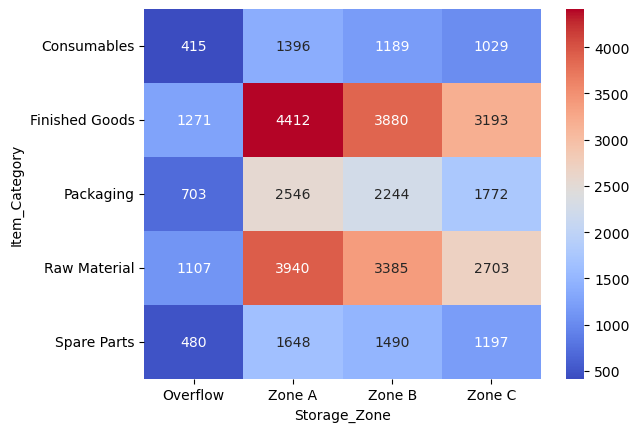

In [71]:
sns.heatmap(pd.crosstab(inventory_profiling['Item_Category'],
                       inventory_profiling['Storage_Zone']),
           annot=True,
           fmt = 'd',
           cmap='coolwarm')

In [72]:
inventory_profiling['Last_Profiled_Date'] = pd.DatetimeIndex(inventory_profiling['Last_Profiled_Date'])

In [73]:
inventory_profiling['Year'] = inventory_profiling['Last_Profiled_Date'].dt.year

In [74]:
inventory_profiling['Month'] = inventory_profiling['Last_Profiled_Date'].dt.month

In [75]:
inventory_profiling['Item_Category'].unique()

array(['Packaging', 'Finished Goods', 'Raw Material', 'Consumables',
       'Spare Parts'], dtype=object)

In [76]:
# This function returns the storage zone wise summary count with respect to particular
# item Category and its priority level 


def ZoneCount_CatWise_and_prioity (Category,priority) :
    data = inventory_profiling[(inventory_profiling['Item_Category']==Category) & 
    (inventory_profiling['Priority_Level']==priority)]

    print (pd.crosstab(data['Warehouse_Code'], data['Storage_Zone']))

    print ('_' * 50)

    print (
        plt.figure(figsize=(5,4)),

        sns.heatmap(pd.crosstab(data['Warehouse_Code'], data['Storage_Zone']),
                   annot=True,
                   cmap='coolwarm',
                   fmt='d',
                   linewidths=0.9),
        
        plt.title(f'Storage Zone Count of {Category} Category with {priority} Priority'),
        plt.ylabel('Warehouse Code'),
        plt.xlabel('Storage Zone'),
        
        plt.show()
          )

Storage_Zone    Overflow  Zone A  Zone B  Zone C
Warehouse_Code                                  
WH_BLR_01             41     124     116      77
WH_CHN_01             27     130     123      90
WH_DEL_01             41     138     116      78
WH_MUM_01             44     140     122     100
WH_NAG_01             32     123      89      73
WH_PUN_01             37     119     110     106
__________________________________________________


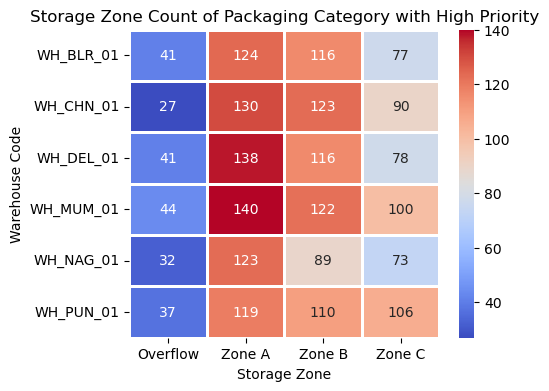

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Storage Zone Count of Packaging Category with High Priority') Text(24.000000000000014, 0.5, 'Warehouse Code') Text(0.5, 24.0, 'Storage Zone') None


In [77]:
ZoneCount_CatWise_and_prioity('Packaging','High')

Storage_Zone    Overflow  Zone A  Zone B  Zone C
Warehouse_Code                                  
WH_BLR_01             54     232     206     178
WH_CHN_01             56     211     210     153
WH_DEL_01             78     233     202     143
WH_MUM_01             58     221     192     154
WH_NAG_01             64     224     190     151
WH_PUN_01             72     198     175     144
__________________________________________________


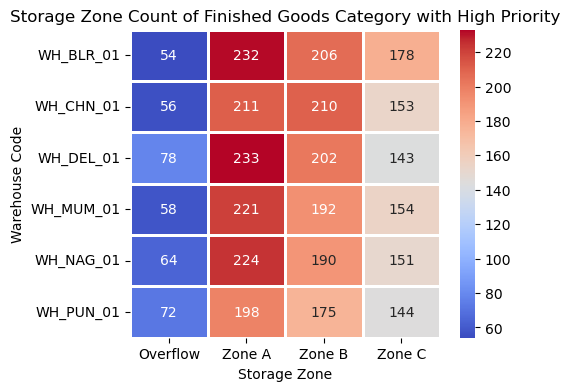

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Storage Zone Count of Finished Goods Category with High Priority') Text(24.784722222222186, 0.5, 'Warehouse Code') Text(0.5, 24.0, 'Storage Zone') None


In [78]:
ZoneCount_CatWise_and_prioity('Finished Goods','High')

Storage_Zone    Overflow  Zone A  Zone B  Zone C
Warehouse_Code                                  
WH_BLR_01             55     198     168     105
WH_CHN_01             56     200     166     152
WH_DEL_01             65     187     160     154
WH_MUM_01             60     190     163     130
WH_NAG_01             52     200     167     138
WH_PUN_01             59     205     168     141
__________________________________________________


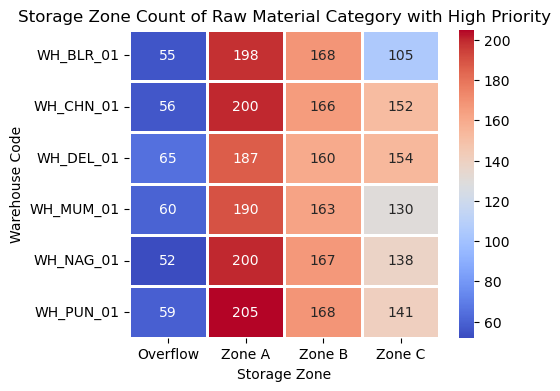

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Storage Zone Count of Raw Material Category with High Priority') Text(24.000000000000014, 0.5, 'Warehouse Code') Text(0.5, 24.0, 'Storage Zone') None


In [79]:
ZoneCount_CatWise_and_prioity('Raw Material','High')

Storage_Zone    Overflow  Zone A  Zone B  Zone C
Warehouse_Code                                  
WH_BLR_01             22      84      49      41
WH_CHN_01             25      82      56      63
WH_DEL_01             17      67      65      42
WH_MUM_01             15      68      73      49
WH_NAG_01             25      69      63      38
WH_PUN_01             20      63      57      56
__________________________________________________


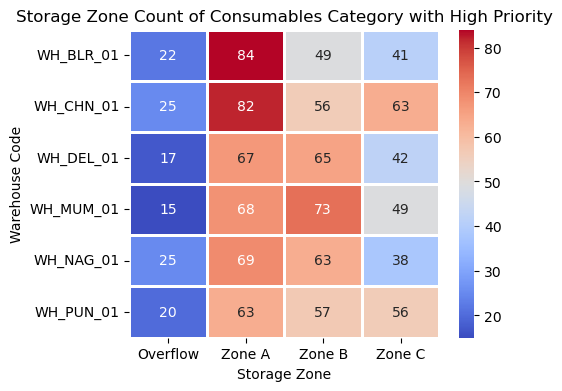

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Storage Zone Count of Consumables Category with High Priority') Text(24.000000000000014, 0.5, 'Warehouse Code') Text(0.5, 24.0, 'Storage Zone') None


In [80]:
ZoneCount_CatWise_and_prioity('Consumables','High')

Storage_Zone    Overflow  Zone A  Zone B  Zone C
Warehouse_Code                                  
WH_BLR_01             22      77      62      57
WH_CHN_01             21      94      65      52
WH_DEL_01             28      80      87      62
WH_MUM_01             26      98      79      53
WH_NAG_01             13      79      90      56
WH_PUN_01             17      79      73      66
__________________________________________________


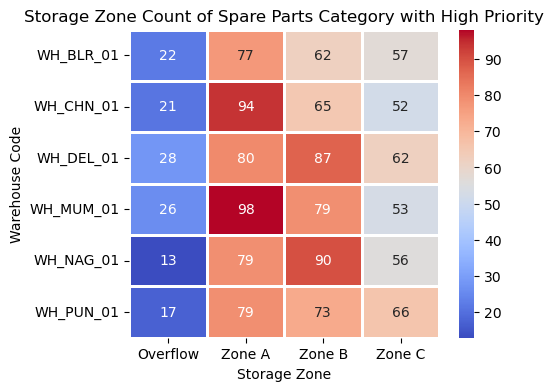

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Storage Zone Count of Spare Parts Category with High Priority') Text(24.000000000000014, 0.5, 'Warehouse Code') Text(0.5, 24.0, 'Storage Zone') None


In [81]:
ZoneCount_CatWise_and_prioity('Spare Parts','High')

Storage_Zone    Overflow  Zone A  Zone B  Zone C
Warehouse_Code                                  
WH_BLR_01             61     186     159     134
WH_CHN_01             62     173     149     107
WH_DEL_01             48     161     169     155
WH_MUM_01             54     181     164     134
WH_NAG_01             46     194     164     130
WH_PUN_01             51     179     169     126
__________________________________________________


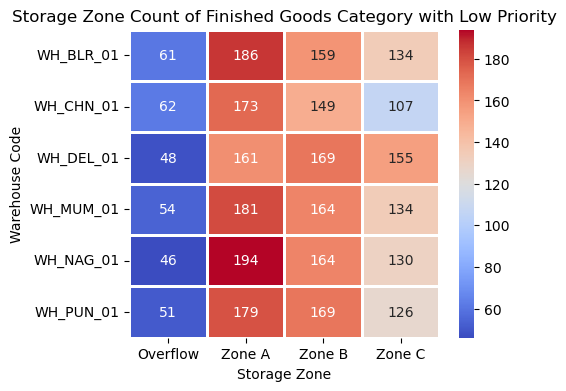

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Storage Zone Count of Finished Goods Category with Low Priority') Text(24.000000000000014, 0.5, 'Warehouse Code') Text(0.5, 24.0, 'Storage Zone') None


In [82]:
ZoneCount_CatWise_and_prioity('Finished Goods','Low')

In [83]:
pd.crosstab(inventory_profiling['Warehouse_Code'], inventory_profiling['Month'] )

Month,1,2,3,4,5,6,7,8,9,10,11,12
Warehouse_Code,,,,,,,,,,,,
WH_BLR_01,524,530,537,610,554,550,580,526,588,563,539,599
WH_CHN_01,563,502,561,535,555,562,576,552,553,547,495,585
WH_DEL_01,568,524,594,547,574,563,584,543,560,584,548,556
WH_MUM_01,580,570,571,521,558,525,525,599,564,570,573,572
WH_NAG_01,573,537,585,530,554,551,574,612,504,552,552,551
WH_PUN_01,551,510,528,555,560,507,616,558,541,549,524,567


In [84]:
pd.crosstab(inventory_profiling['Warehouse_Code'], inventory_profiling['Year'] )

Year,2023,2024
Warehouse_Code,,
WH_BLR_01,3302,3398
WH_CHN_01,3218,3368
WH_DEL_01,3311,3434
WH_MUM_01,3362,3366
WH_NAG_01,3309,3366
WH_PUN_01,3344,3222


# Multivariate Analysis on 'inventory_validation'

In [85]:
inventory_validation.head(2)

,Validation_ID,Movement_ID,Validation_Date,Validation_Rule,Validation_Status,Validator,Remarks
0,VAL7000000,MOV3000004,2023-03-23,UOM consistency,Pass,auditor_suresh,NaN
1,VAL7000001,MOV3000012,2021-11-14,ERP posting validation,Pass,system_auto,NaN


In [86]:
inventory_validation['Validation_Date'] = pd.DatetimeIndex(inventory_validation['Validation_Date'])

In [87]:
inventory_validation['Validation_Date'].dtype

dtype('<M8[ns]')

In [88]:
inventory_validation['Year'] = inventory_validation['Validation_Date'].dt.year

In [89]:
inventory_validation['Month'] = inventory_validation['Validation_Date'].dt.month

In [90]:
inventory_validation['Month'] = inventory_validation['Month'].replace({
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
})

In [91]:
inventory_validation.sample(2)

,Validation_ID,Movement_ID,Validation_Date,Validation_Rule,Validation_Status,Validator,Remarks,Year,Month
9559,VAL7009559,MOV3094560,2022-01-20,Quantity tolerance check,Fail,auditor_pooja,Requires correction as per SOP,2022,January
8783,VAL7008783,MOV3086698,2022-12-18,Quantity tolerance check,Fail,system_auto,Requires correction as per SOP,2022,December


In [92]:
inventory_validation['Year'].value_counts()

Year
2021    5183
2022    5168
2023    5129
2024    5084
Name: count, dtype: int64

In [93]:
inventory_validation['Month'].value_counts().reset_index(name='count').sort_values(
    by='count', ascending=False
)

,Month,count
0,March,1813
1,May,1788
2,August,1775
3,November,1746
4,June,1736
5,October,1727
6,December,1721
7,April,1711
8,September,1685
9,January,1660


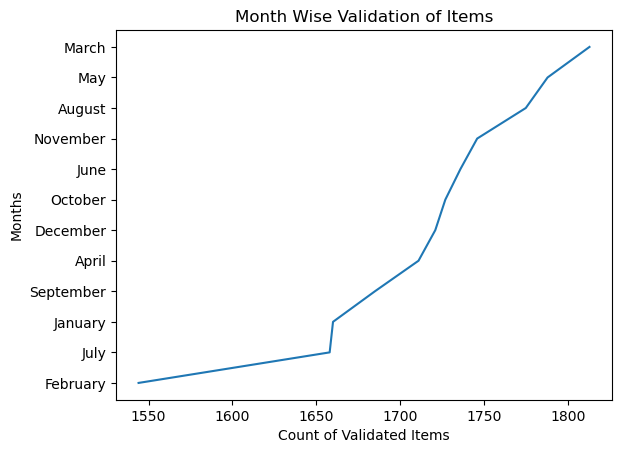

In [94]:
sns.lineplot(data = inventory_validation['Month'].value_counts().reset_index(name='count').sort_values(
    by='count', ascending=False),
            x = 'count', y = 'Month')

plt.title('Month Wise Validation of Items'),
plt.xlabel('Count of Validated Items'),
plt.ylabel('Months'),

plt.show()

In [95]:
inventory_validation['Validation_Rule'].unique()

array(['UOM consistency', 'ERP posting validation',
       'Document completeness', 'Warehouse-location match',
       'Quantity tolerance check'], dtype=object)

# Created reusable Function

In [96]:
# This function returns the distribution of validated items by year and validator
# based on the selected Validation Rule and Validation Status.

def ValidationRuleANDstatusWise_Dist (Validation_Rule,Validation_Status) :
    data = inventory_validation[(inventory_validation['Validation_Rule']==Validation_Rule) & 
        (inventory_validation['Validation_Status']==Validation_Status)]

    print (
        f"Total Count of Validated Items which has comes under {Validation_Rule} rule and \n"
        f"Validation Status is {Validation_Status} =  {data.shape[0]}"
    )

    print ('_' * 80)

    print (
        pd.crosstab(data['Validator'], data['Year'])
    )

    print (
        plt.figure(figsize=(5,4)),

        sns.heatmap(pd.crosstab(data['Validator'], data['Year']),
                   annot=True,
                   cmap='coolwarm',
                   fmt='d',
                   linewidths=0.9),
        
        plt.title(f'Distribution of validation {Validation_Status} under {Validation_Rule} rule'),
        plt.ylabel('Name of the Validator'),
        plt.xlabel('Year of Validation'),
        
        plt.show()
    )

Total Count of Validated Items which has comes under UOM consistency rule and 
Validation Status is Pass =  3231
________________________________________________________________________________
Year            2021  2022  2023  2024
Validator                             
auditor_neha     153   160   157   163
auditor_pooja    187   164   165   163
auditor_raj      162   163   154   160
auditor_suresh   158   137   145   184
system_auto      172   168   152   164


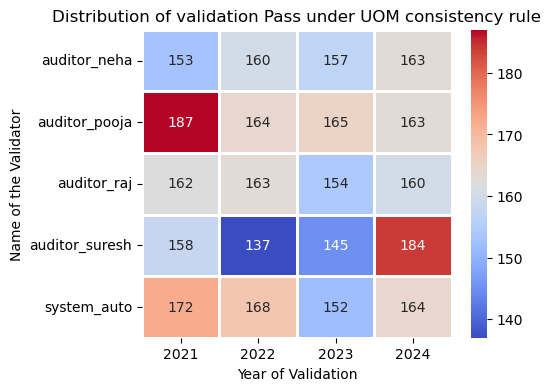

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Distribution of validation Pass under UOM consistency rule') Text(24.000000000000014, 0.5, 'Name of the Validator') Text(0.5, 24.0, 'Year of Validation') None


In [97]:
ValidationRuleANDstatusWise_Dist('UOM consistency','Pass')

Total Count of Validated Items which has comes under UOM consistency rule and 
Validation Status is Fail =  908
________________________________________________________________________________
Year            2021  2022  2023  2024
Validator                             
auditor_neha      52    50    50    32
auditor_pooja     40    51    49    39
auditor_raj       35    49    47    52
auditor_suresh    47    59    36    38
system_auto       44    48    41    49


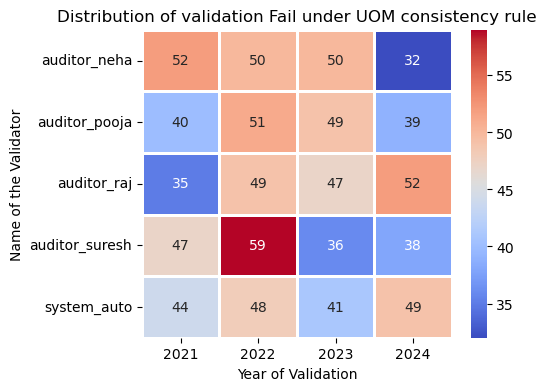

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Distribution of validation Fail under UOM consistency rule') Text(24.000000000000014, 0.5, 'Name of the Validator') Text(0.5, 24.0, 'Year of Validation') None


In [98]:
ValidationRuleANDstatusWise_Dist('UOM consistency','Fail')

Total Count of Validated Items which has comes under ERP posting validation rule and 
Validation Status is Pass =  3145
________________________________________________________________________________
Year            2021  2022  2023  2024
Validator                             
auditor_neha     134   154   169   155
auditor_pooja    155   153   154   150
auditor_raj      159   172   166   160
auditor_suresh   167   156   152   173
system_auto      169   151   154   142


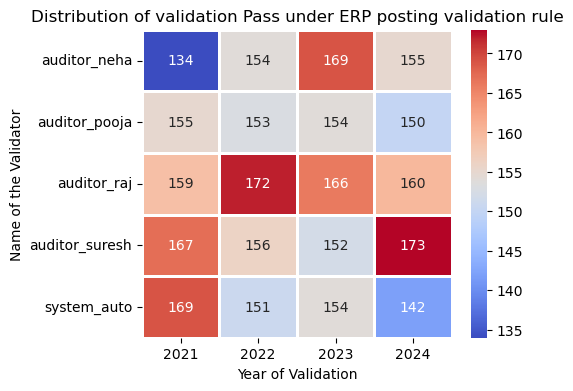

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Distribution of validation Pass under ERP posting validation rule') Text(24.000000000000014, 0.5, 'Name of the Validator') Text(0.5, 24.0, 'Year of Validation') None


In [99]:
ValidationRuleANDstatusWise_Dist('ERP posting validation','Pass')

Total Count of Validated Items which has comes under ERP posting validation rule and 
Validation Status is Fail =  846
________________________________________________________________________________
Year            2021  2022  2023  2024
Validator                             
auditor_neha      40    36    42    57
auditor_pooja     35    39    39    47
auditor_raj       35    43    46    49
auditor_suresh    37    44    36    56
system_auto       44    36    40    45


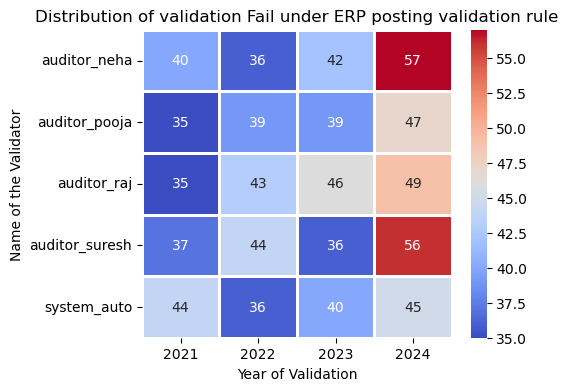

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Distribution of validation Fail under ERP posting validation rule') Text(24.000000000000014, 0.5, 'Name of the Validator') Text(0.5, 24.0, 'Year of Validation') None


In [100]:
ValidationRuleANDstatusWise_Dist('ERP posting validation','Fail')

Total Count of Validated Items which has comes under Document completeness rule and 
Validation Status is Pass =  3240
________________________________________________________________________________
Year            2021  2022  2023  2024
Validator                             
auditor_neha     161   174   163   150
auditor_pooja    186   144   151   142
auditor_raj      160   160   152   161
auditor_suresh   188   168   166   157
system_auto      163   161   164   169


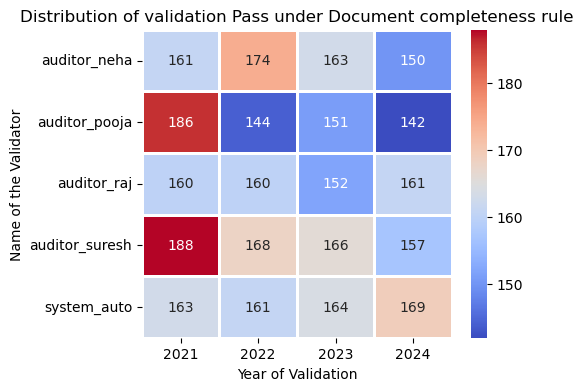

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Distribution of validation Pass under Document completeness rule') Text(24.000000000000014, 0.5, 'Name of the Validator') Text(0.5, 24.0, 'Year of Validation') None


In [101]:
ValidationRuleANDstatusWise_Dist('Document completeness','Pass')

Total Count of Validated Items which has comes under Document completeness rule and 
Validation Status is Fail =  939
________________________________________________________________________________
Year            2021  2022  2023  2024
Validator                             
auditor_neha      51    52    59    47
auditor_pooja     47    47    42    53
auditor_raj       46    54    51    36
auditor_suresh    43    44    35    42
system_auto       38    52    53    47


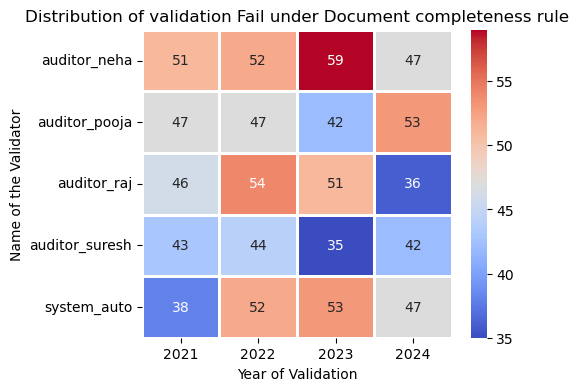

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Distribution of validation Fail under Document completeness rule') Text(24.000000000000014, 0.5, 'Name of the Validator') Text(0.5, 24.0, 'Year of Validation') None


In [102]:
ValidationRuleANDstatusWise_Dist('Document completeness','Fail')

Total Count of Validated Items which has comes under Warehouse-location match rule and 
Validation Status is Pass =  3184
________________________________________________________________________________
Year            2021  2022  2023  2024
Validator                             
auditor_neha     148   150   164   143
auditor_pooja    151   167   170   162
auditor_raj      175   132   143   159
auditor_suresh   157   192   158   164
system_auto      165   158   160   166


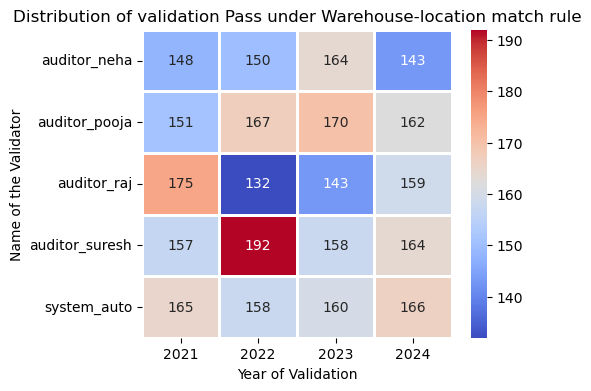

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Distribution of validation Pass under Warehouse-location match rule') Text(24.000000000000014, 0.5, 'Name of the Validator') Text(0.5, 24.0, 'Year of Validation') None


In [103]:
ValidationRuleANDstatusWise_Dist('Warehouse-location match','Pass')

Total Count of Validated Items which has comes under Warehouse-location match rule and 
Validation Status is Fail =  885
________________________________________________________________________________
Year            2021  2022  2023  2024
Validator                             
auditor_neha      46    41    53    41
auditor_pooja     51    48    48    36
auditor_raj       40    43    41    36
auditor_suresh    44    45    47    35
system_auto       58    43    37    52


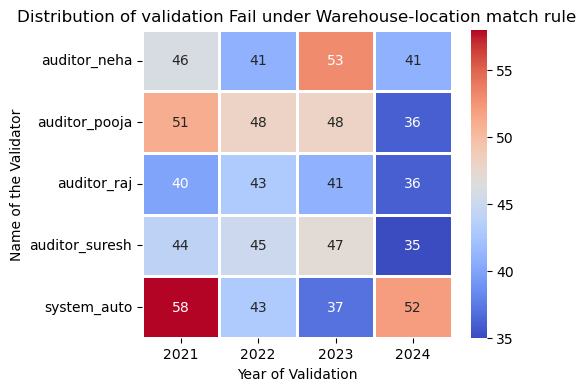

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Distribution of validation Fail under Warehouse-location match rule') Text(24.000000000000014, 0.5, 'Name of the Validator') Text(0.5, 24.0, 'Year of Validation') None


In [104]:
ValidationRuleANDstatusWise_Dist('Warehouse-location match','Fail')

Total Count of Validated Items which has comes under Quantity tolerance check rule and 
Validation Status is Pass =  3268
________________________________________________________________________________
Year            2021  2022  2023  2024
Validator                             
auditor_neha     159   178   164   158
auditor_pooja    161   161   158   167
auditor_raj      148   170   187   140
auditor_suresh   171   161   184   171
system_auto      158   160   160   152


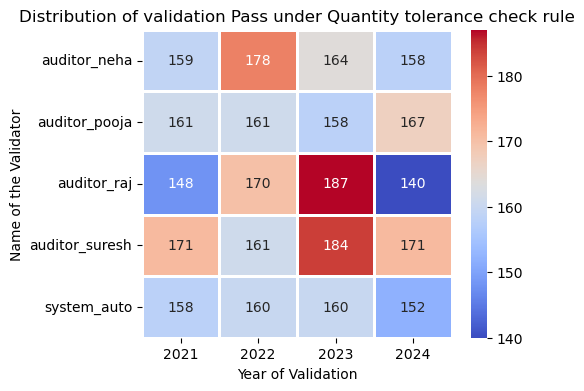

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Distribution of validation Pass under Quantity tolerance check rule') Text(24.000000000000014, 0.5, 'Name of the Validator') Text(0.5, 24.0, 'Year of Validation') None


In [105]:
ValidationRuleANDstatusWise_Dist('Quantity tolerance check','Pass')

Total Count of Validated Items which has comes under Quantity tolerance check rule and 
Validation Status is Fail =  918
________________________________________________________________________________
Year            2021  2022  2023  2024
Validator                             
auditor_neha      50    33    43    50
auditor_pooja     57    59    52    42
auditor_raj       39    46    40    49
auditor_suresh    39    43    41    45
system_auto       58    49    49    34


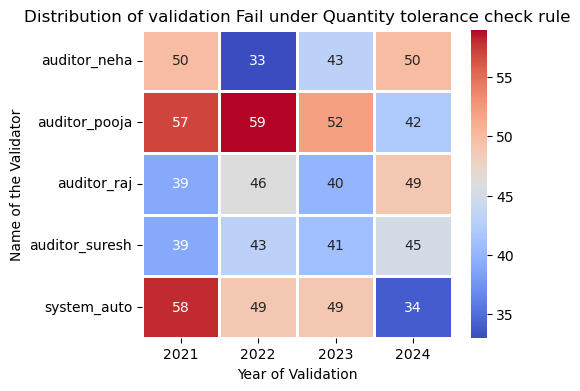

Figure(500x400) Axes(0.125,0.11;0.62x0.77) Text(0.5, 1.0, 'Distribution of validation Fail under Quantity tolerance check rule') Text(24.000000000000014, 0.5, 'Name of the Validator') Text(0.5, 24.0, 'Year of Validation') None


In [106]:
ValidationRuleANDstatusWise_Dist('Quantity tolerance check','Fail')

In [107]:
inventory_validation['Validation_Rule'].unique()

array(['UOM consistency', 'ERP posting validation',
       'Document completeness', 'Warehouse-location match',
       'Quantity tolerance check'], dtype=object)

In [108]:
inventory_validation['Validation_Status'].unique()

array(['Pass', 'Fail'], dtype=object)

# Multivariate Analysis on 'task_allocation'

In [109]:
task_allocation.head(3)

,Task_ID,Task_Date,Item_ID,Warehouse_Code,Task_Type,Assigned_Staff,Assigned_Quantity,Task_Status
0,TASK2000000,2022-09-20,ITEM131928,WH_BLR_01,Picking,staff_ajay,14,Completed
1,TASK2000001,2023-04-04,ITEM110442,WH_CHN_01,Cycle Count,staff_sonal,21,Completed
2,TASK2000002,2021-11-11,ITEM119005,WH_BLR_01,Packing,staff_vikas,20,Completed


In [110]:
task_allocation['Task_Date'] = pd.DatetimeIndex(task_allocation['Task_Date'])

In [111]:
task_allocation['Task_Date'].dtype

dtype('<M8[ns]')

In [112]:
task_allocation['Year'] = task_allocation['Task_Date'].dt.year

In [113]:
task_allocation['Month'] = task_allocation['Task_Date'].dt.month

In [114]:
task_allocation['Month'] = task_allocation['Month'].replace({
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
})

In [115]:
task_allocation.groupby(
    ['Warehouse_Code','Assigned_Staff'])['Assigned_Quantity'].sum().reset_index(name='count')

,Warehouse_Code,Assigned_Staff,count
0,WH_BLR_01,staff_ajay,59776
1,WH_BLR_01,staff_amit,41675
2,WH_BLR_01,staff_kiran,33926
3,WH_BLR_01,staff_priya,41470
4,WH_BLR_01,staff_rohit,49436
5,WH_BLR_01,staff_sneha,46838
6,WH_BLR_01,staff_sonal,34084
7,WH_BLR_01,staff_vikas,29828
8,WH_CHN_01,staff_ajay,60456
9,WH_CHN_01,staff_amit,40843


<Axes: xlabel='count', ylabel='Assigned_Staff'>

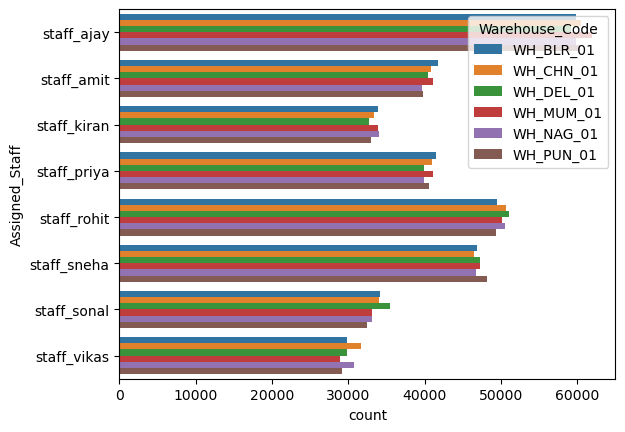

In [116]:
sns.barplot(
    data = (task_allocation.groupby(
    ['Warehouse_Code','Assigned_Staff'])['Assigned_Quantity'].sum().reset_index(name='count')),
    x = 'count',
    y = 'Assigned_Staff',
    hue = 'Warehouse_Code'
)

In [117]:
ajay = task_allocation[task_allocation['Assigned_Staff']=='staff_ajay']

In [118]:
ajay['Assigned_Quantity'].sum()

np.int64(361343)

In [119]:
vikas = task_allocation[task_allocation['Assigned_Staff']=='staff_vikas']

In [120]:
vikas['Assigned_Quantity'].sum()

np.int64(179949)

In [121]:
task_allocation.groupby(['Month'])['Assigned_Quantity'].sum().reset_index(name='count').sort_values(
    by='count', ascending=True)

,Month,count
3,February,154670
9,November,164855
6,June,165199
0,April,165557
11,September,167248
4,January,169795
7,March,170397
5,July,170626
8,May,170857
1,August,171281


<Axes: xlabel='count', ylabel='Month'>

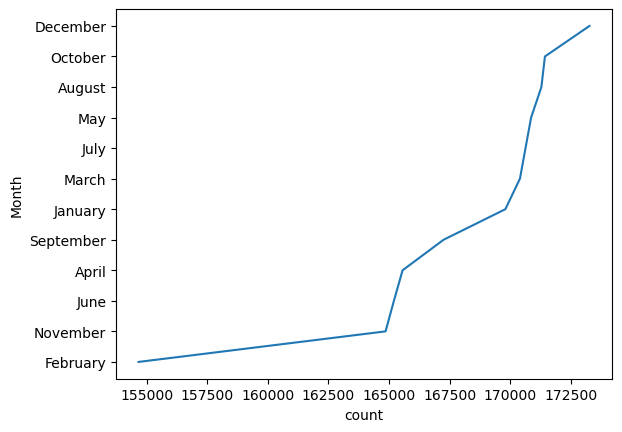

In [122]:
sns.lineplot(
    data = (task_allocation.groupby(['Month'])
        ['Assigned_Quantity'].sum().reset_index(name='count').sort_values(
    by='count', ascending=False)),
    x = 'count', y = 'Month'
)

In [123]:

# This function returns the task Type wise summary for a selected staff member across all warehouses

def task_completion_check(Assigned_Staff):

    data = task_allocation[
        task_allocation['Assigned_Staff'] == Assigned_Staff
    ]
    
    print(f"{Assigned_Staff} has been assigned a total of {data.shape[0]} tasks")

    print('_' * 80)

    print(f"{Assigned_Staff} has been assigned a total quantity of {data['Assigned_Quantity'].sum()}")

    print('_' * 80)

    print("Task Type-wise Summary:")

    task_summary = data.groupby(['Warehouse_Code', 'Task_Type']).size().reset_index(name='Count')

    print(task_summary)

    # For plotting any chart we dont need to give print() statement-----For Self information
    
    sns.barplot(
        data = task_summary,
        x = 'Count',
        y = 'Warehouse_Code',
        hue = 'Task_Type'
    )

    plt.title(f"Task Type-wise Distribution of Tasks Assigned to {Assigned_Staff}")
    plt.ylabel("Warehouse Code")
    plt.xlabel("Count by Task Type")
    plt.show()

    print('_' * 80)

    print("Warehouse-wise and Task Status-wise Summary:")

    warehouse_summary = data.groupby(
        ['Warehouse_Code', 'Task_Status', 'Task_Type']
        ).size().reset_index(name='Count').sort_values(by='Count',ascending=True
    )

    print(warehouse_summary)

    print('_' * 80)

    # For plotting any chart we dont need to give print() statement-----For Self information
    
    sns.barplot(
        data =warehouse_summary,
        x = 'Count',
        y = 'Warehouse_Code',
        hue = 'Task_Status'
    )

    plt.title(f"Distribution of Task Status of {Assigned_Staff} Across Warehouses")
    plt.ylabel("Warehouse Code")
    plt.xlabel("Count by Task Status")
    plt.show()

In [124]:
task_allocation['Assigned_Staff'].unique()

array(['staff_ajay', 'staff_sonal', 'staff_vikas', 'staff_sneha',
       'staff_kiran', 'staff_rohit', 'staff_amit', 'staff_priya'],
      dtype=object)

staff_ajay has been assigned a total of 17944 tasks
________________________________________________________________________________
staff_ajay has been assigned a total quantity of 361343
________________________________________________________________________________
Task Type-wise Summary:
   Warehouse_Code             Task_Type  Count
0       WH_BLR_01           Cycle Count    460
1       WH_BLR_01  Inbound Verification    422
2       WH_BLR_01     Outbound Dispatch    404
3       WH_BLR_01               Packing    405
4       WH_BLR_01               Picking    442
5       WH_BLR_01               Putaway    428
6       WH_BLR_01        Stock Transfer    429
7       WH_CHN_01           Cycle Count    455
8       WH_CHN_01  Inbound Verification    453
9       WH_CHN_01     Outbound Dispatch    405
10      WH_CHN_01               Packing    387
11      WH_CHN_01               Picking    411
12      WH_CHN_01               Putaway    408
13      WH_CHN_01        Stock Transfer    458
1

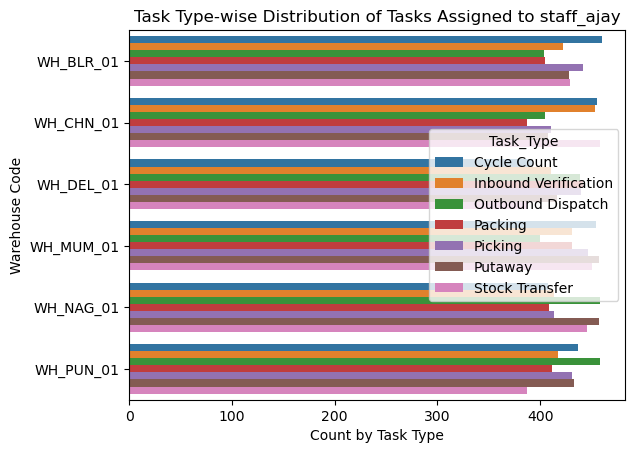

________________________________________________________________________________
Warehouse-wise and Task Status-wise Summary:
    Warehouse_Code Task_Status          Task_Type  Count
24       WH_CHN_01   Cancelled            Packing     11
84       WH_NAG_01   Cancelled        Cycle Count     14
88       WH_NAG_01   Cancelled            Picking     14
46       WH_DEL_01   Cancelled            Picking     15
2        WH_BLR_01   Cancelled  Outbound Dispatch     15
..             ...         ...                ...    ...
7        WH_BLR_01   Completed        Cycle Count    390
75       WH_MUM_01   Completed            Putaway    390
28       WH_CHN_01   Completed        Cycle Count    391
93       WH_NAG_01   Completed  Outbound Dispatch    399
114      WH_PUN_01   Completed  Outbound Dispatch    400

[126 rows x 4 columns]
________________________________________________________________________________


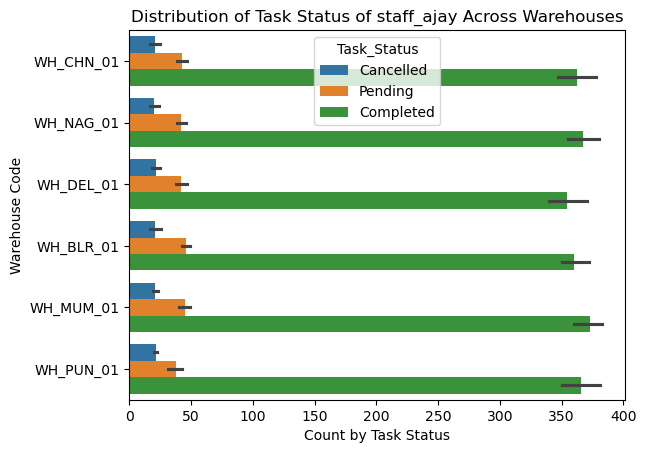

In [125]:
task_completion_check ('staff_ajay')

staff_sonal has been assigned a total of 9946 tasks
________________________________________________________________________________
staff_sonal has been assigned a total quantity of 202219
________________________________________________________________________________
Task Type-wise Summary:
   Warehouse_Code             Task_Type  Count
0       WH_BLR_01           Cycle Count    233
1       WH_BLR_01  Inbound Verification    246
2       WH_BLR_01     Outbound Dispatch    241
3       WH_BLR_01               Packing    255
4       WH_BLR_01               Picking    234
5       WH_BLR_01               Putaway    232
6       WH_BLR_01        Stock Transfer    244
7       WH_CHN_01           Cycle Count    240
8       WH_CHN_01  Inbound Verification    255
9       WH_CHN_01     Outbound Dispatch    233
10      WH_CHN_01               Packing    243
11      WH_CHN_01               Picking    254
12      WH_CHN_01               Putaway    224
13      WH_CHN_01        Stock Transfer    218


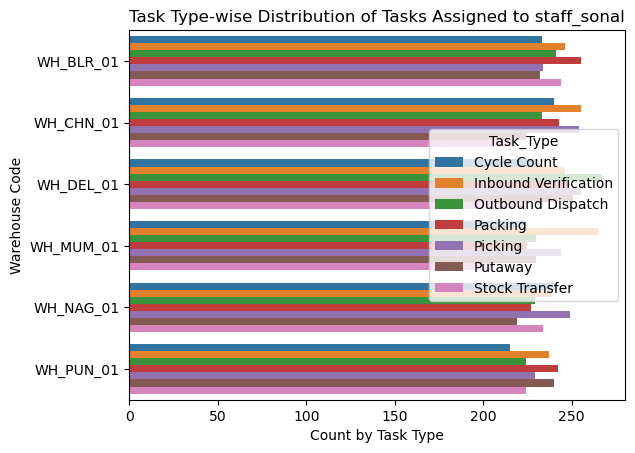

________________________________________________________________________________
Warehouse-wise and Task Status-wise Summary:
   Warehouse_Code Task_Status             Task_Type  Count
89      WH_NAG_01   Cancelled               Putaway      5
67      WH_MUM_01   Cancelled               Picking      6
4       WH_BLR_01   Cancelled               Picking      7
48      WH_DEL_01   Cancelled        Stock Transfer      7
69      WH_MUM_01   Cancelled        Stock Transfer      8
..            ...         ...                   ...    ...
29      WH_CHN_01   Completed  Inbound Verification    217
54      WH_DEL_01   Completed               Putaway    218
53      WH_DEL_01   Completed               Picking    220
71      WH_MUM_01   Completed  Inbound Verification    226
51      WH_DEL_01   Completed     Outbound Dispatch    233

[126 rows x 4 columns]
________________________________________________________________________________


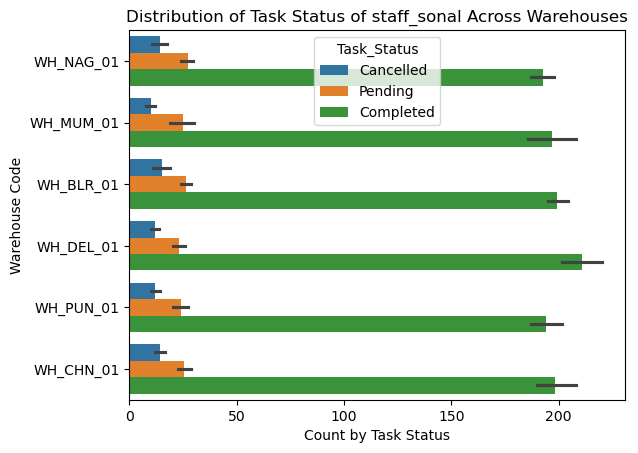

In [126]:
task_completion_check ('staff_sonal')

staff_vikas has been assigned a total of 8952 tasks
________________________________________________________________________________
staff_vikas has been assigned a total quantity of 179949
________________________________________________________________________________
Task Type-wise Summary:
   Warehouse_Code             Task_Type  Count
0       WH_BLR_01           Cycle Count    205
1       WH_BLR_01  Inbound Verification    201
2       WH_BLR_01     Outbound Dispatch    209
3       WH_BLR_01               Packing    220
4       WH_BLR_01               Picking    214
5       WH_BLR_01               Putaway    227
6       WH_BLR_01        Stock Transfer    228
7       WH_CHN_01           Cycle Count    203
8       WH_CHN_01  Inbound Verification    216
9       WH_CHN_01     Outbound Dispatch    206
10      WH_CHN_01               Packing    218
11      WH_CHN_01               Picking    231
12      WH_CHN_01               Putaway    203
13      WH_CHN_01        Stock Transfer    228


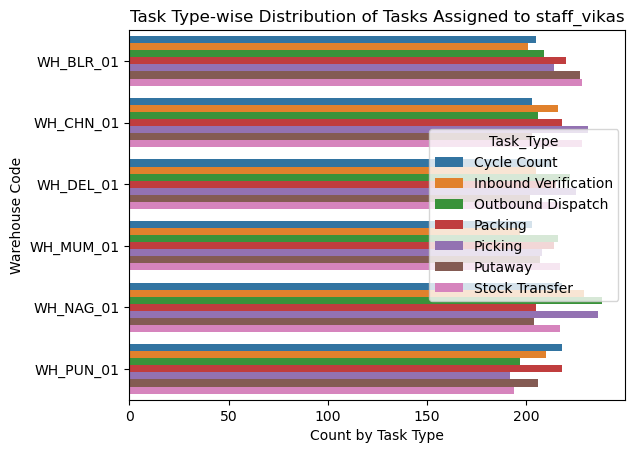

________________________________________________________________________________
Warehouse-wise and Task Status-wise Summary:
    Warehouse_Code Task_Status             Task_Type  Count
4        WH_BLR_01   Cancelled               Picking      4
105      WH_PUN_01   Cancelled           Cycle Count      4
6        WH_BLR_01   Cancelled        Stock Transfer      5
22       WH_CHN_01   Cancelled  Inbound Verification      5
90       WH_NAG_01   Cancelled        Stock Transfer      5
..             ...         ...                   ...    ...
51       WH_DEL_01   Completed     Outbound Dispatch    195
53       WH_DEL_01   Completed               Picking    196
32       WH_CHN_01   Completed               Picking    200
12       WH_BLR_01   Completed               Putaway    200
95       WH_NAG_01   Completed               Picking    204

[126 rows x 4 columns]
________________________________________________________________________________


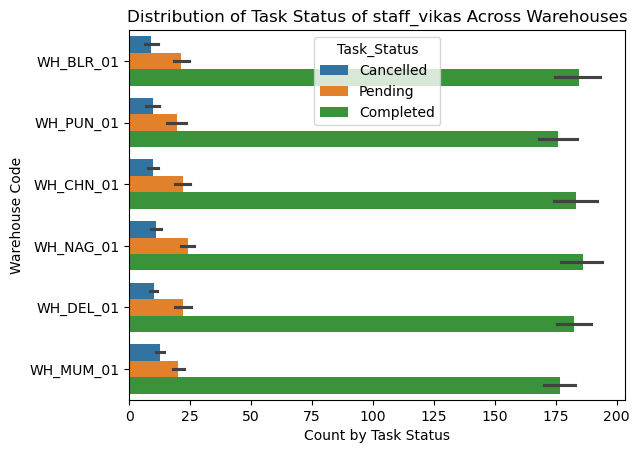

In [127]:
task_completion_check ('staff_vikas')

staff_sneha has been assigned a total of 14004 tasks
________________________________________________________________________________
staff_sneha has been assigned a total quantity of 282569
________________________________________________________________________________
Task Type-wise Summary:
   Warehouse_Code             Task_Type  Count
0       WH_BLR_01           Cycle Count    329
1       WH_BLR_01  Inbound Verification    332
2       WH_BLR_01     Outbound Dispatch    313
3       WH_BLR_01               Packing    325
4       WH_BLR_01               Picking    367
5       WH_BLR_01               Putaway    329
6       WH_BLR_01        Stock Transfer    340
7       WH_CHN_01           Cycle Count    339
8       WH_CHN_01  Inbound Verification    315
9       WH_CHN_01     Outbound Dispatch    304
10      WH_CHN_01               Packing    308
11      WH_CHN_01               Picking    335
12      WH_CHN_01               Putaway    353
13      WH_CHN_01        Stock Transfer    331

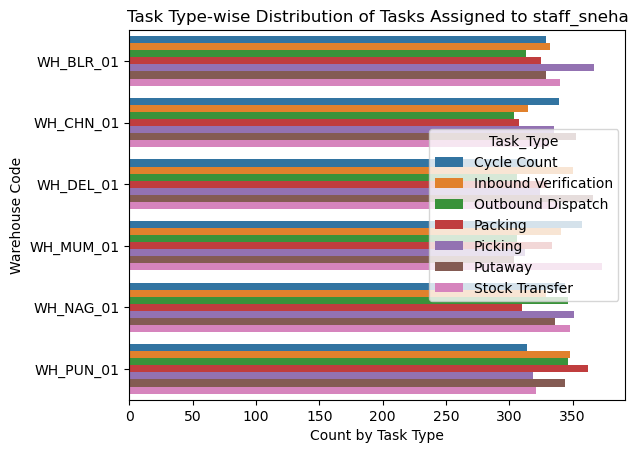

________________________________________________________________________________
Warehouse-wise and Task Status-wise Summary:
    Warehouse_Code Task_Status             Task_Type  Count
42       WH_DEL_01   Cancelled           Cycle Count     10
23       WH_CHN_01   Cancelled     Outbound Dispatch     10
5        WH_BLR_01   Cancelled               Putaway     11
107      WH_PUN_01   Cancelled     Outbound Dispatch     12
27       WH_CHN_01   Cancelled        Stock Transfer     13
..             ...         ...                   ...    ...
115      WH_PUN_01   Completed               Packing    301
50       WH_DEL_01   Completed  Inbound Verification    301
54       WH_DEL_01   Completed               Putaway    302
114      WH_PUN_01   Completed     Outbound Dispatch    307
76       WH_MUM_01   Completed        Stock Transfer    315

[126 rows x 4 columns]
________________________________________________________________________________


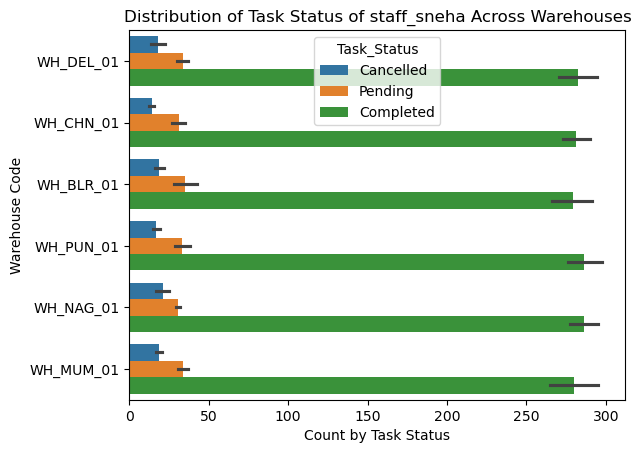

In [128]:
task_completion_check ('staff_sneha')

staff_kiran has been assigned a total of 9991 tasks
________________________________________________________________________________
staff_kiran has been assigned a total quantity of 200756
________________________________________________________________________________
Task Type-wise Summary:
   Warehouse_Code             Task_Type  Count
0       WH_BLR_01           Cycle Count    241
1       WH_BLR_01  Inbound Verification    228
2       WH_BLR_01     Outbound Dispatch    231
3       WH_BLR_01               Packing    236
4       WH_BLR_01               Picking    260
5       WH_BLR_01               Putaway    254
6       WH_BLR_01        Stock Transfer    238
7       WH_CHN_01           Cycle Count    226
8       WH_CHN_01  Inbound Verification    247
9       WH_CHN_01     Outbound Dispatch    236
10      WH_CHN_01               Packing    233
11      WH_CHN_01               Picking    225
12      WH_CHN_01               Putaway    260
13      WH_CHN_01        Stock Transfer    201


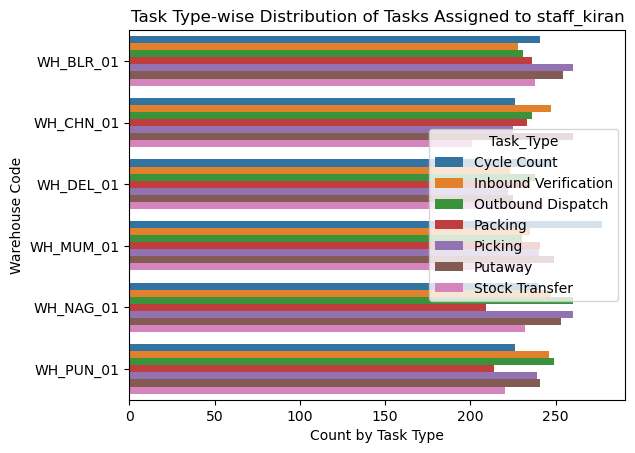

________________________________________________________________________________
Warehouse-wise and Task Status-wise Summary:
   Warehouse_Code Task_Status          Task_Type  Count
26      WH_CHN_01   Cancelled            Putaway      1
89      WH_NAG_01   Cancelled            Putaway      6
2       WH_BLR_01   Cancelled  Outbound Dispatch      6
45      WH_DEL_01   Cancelled            Packing      8
46      WH_DEL_01   Cancelled            Picking      8
..            ...         ...                ...    ...
93      WH_NAG_01   Completed  Outbound Dispatch    222
96      WH_NAG_01   Completed            Putaway    226
11      WH_BLR_01   Completed            Picking    229
33      WH_CHN_01   Completed            Putaway    239
70      WH_MUM_01   Completed        Cycle Count    240

[126 rows x 4 columns]
________________________________________________________________________________


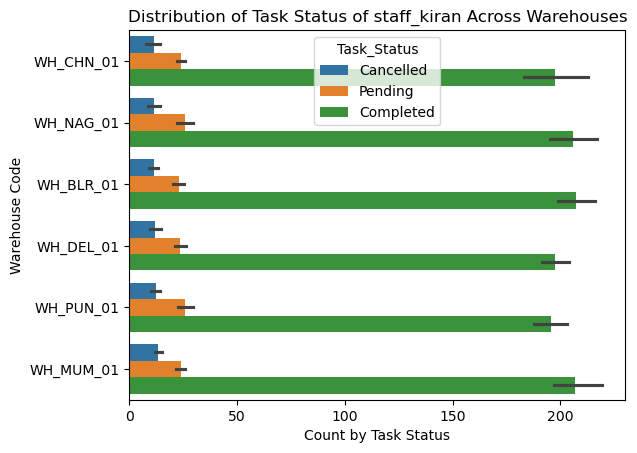

In [129]:
task_completion_check ('staff_kiran')

staff_rohit has been assigned a total of 15050 tasks
________________________________________________________________________________
staff_rohit has been assigned a total quantity of 301013
________________________________________________________________________________
Task Type-wise Summary:
   Warehouse_Code             Task_Type  Count
0       WH_BLR_01           Cycle Count    367
1       WH_BLR_01  Inbound Verification    347
2       WH_BLR_01     Outbound Dispatch    348
3       WH_BLR_01               Packing    361
4       WH_BLR_01               Picking    351
5       WH_BLR_01               Putaway    367
6       WH_BLR_01        Stock Transfer    365
7       WH_CHN_01           Cycle Count    336
8       WH_CHN_01  Inbound Verification    352
9       WH_CHN_01     Outbound Dispatch    379
10      WH_CHN_01               Packing    363
11      WH_CHN_01               Picking    387
12      WH_CHN_01               Putaway    338
13      WH_CHN_01        Stock Transfer    356

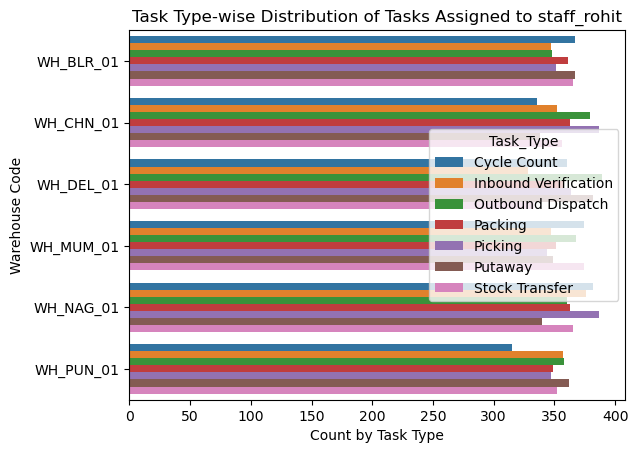

________________________________________________________________________________
Warehouse-wise and Task Status-wise Summary:
   Warehouse_Code Task_Status             Task_Type  Count
85      WH_NAG_01   Cancelled  Inbound Verification     11
43      WH_DEL_01   Cancelled  Inbound Verification     14
68      WH_MUM_01   Cancelled               Putaway     14
66      WH_MUM_01   Cancelled               Packing     14
65      WH_MUM_01   Cancelled     Outbound Dispatch     14
..            ...         ...                   ...    ...
30      WH_CHN_01   Completed     Outbound Dispatch    330
91      WH_NAG_01   Completed           Cycle Count    330
54      WH_DEL_01   Completed               Putaway    331
92      WH_NAG_01   Completed  Inbound Verification    332
32      WH_CHN_01   Completed               Picking    340

[126 rows x 4 columns]
________________________________________________________________________________


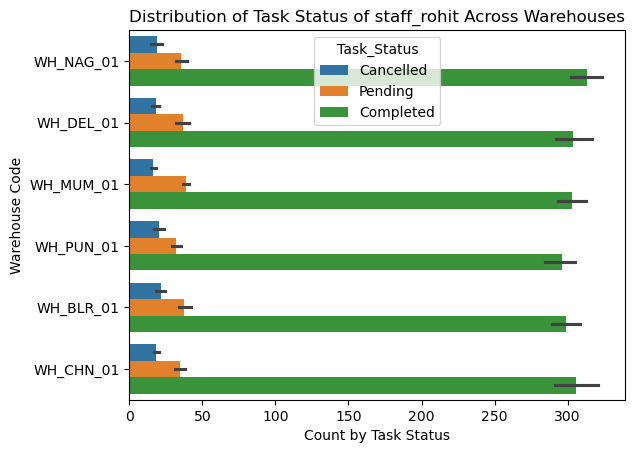

In [130]:
task_completion_check ('staff_rohit')

staff_priya has been assigned a total of 12107 tasks
________________________________________________________________________________
staff_priya has been assigned a total quantity of 243836
________________________________________________________________________________
Task Type-wise Summary:
   Warehouse_Code             Task_Type  Count
0       WH_BLR_01           Cycle Count    279
1       WH_BLR_01  Inbound Verification    291
2       WH_BLR_01     Outbound Dispatch    304
3       WH_BLR_01               Packing    286
4       WH_BLR_01               Picking    276
5       WH_BLR_01               Putaway    299
6       WH_BLR_01        Stock Transfer    300
7       WH_CHN_01           Cycle Count    283
8       WH_CHN_01  Inbound Verification    288
9       WH_CHN_01     Outbound Dispatch    289
10      WH_CHN_01               Packing    314
11      WH_CHN_01               Picking    303
12      WH_CHN_01               Putaway    289
13      WH_CHN_01        Stock Transfer    279

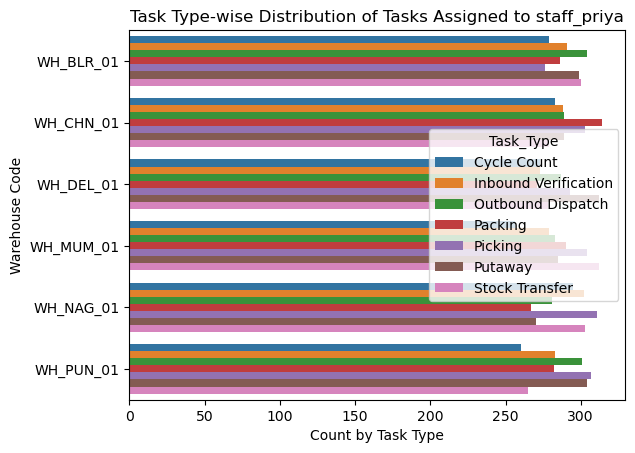

________________________________________________________________________________
Warehouse-wise and Task Status-wise Summary:
    Warehouse_Code Task_Status       Task_Type  Count
68       WH_MUM_01   Cancelled         Putaway      7
90       WH_NAG_01   Cancelled  Stock Transfer      8
26       WH_CHN_01   Cancelled         Putaway      9
89       WH_NAG_01   Cancelled         Putaway      9
42       WH_DEL_01   Cancelled     Cycle Count     10
..             ...         ...             ...    ...
117      WH_PUN_01   Completed         Putaway    264
97       WH_NAG_01   Completed  Stock Transfer    264
31       WH_CHN_01   Completed         Packing    266
76       WH_MUM_01   Completed  Stock Transfer    266
95       WH_NAG_01   Completed         Picking    273

[126 rows x 4 columns]
________________________________________________________________________________


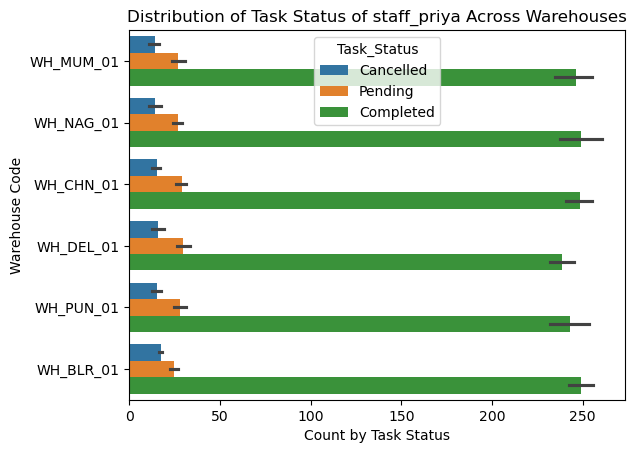

In [131]:
task_completion_check ('staff_priya')

# Business Problems - Analysis

# 1st Statement : Which warehouses are creating the most discrepancies and why?

In [132]:
# Identifying high discrepancy warehouses

discrepancy_log.groupby('Warehouse_Code')['Variance_Quantity'].sum().reset_index(name='count')\
    .sort_values(by='count',ascending=True)


,Warehouse_Code,count
1,WH_CHN_01,-1413
2,WH_DEL_01,-966
3,WH_MUM_01,-873
5,WH_PUN_01,-845
4,WH_NAG_01,-460
0,WH_BLR_01,-435


In [133]:
# In which item category, descripancies are higher?

merged_discrepancy_item = pd.merge(discrepancy_log,inventory_item, on = 'Item_ID')

In [134]:
merged_discrepancy_item.head(1)

,Discrepancy_ID,Movement_ID,Item_ID,Warehouse_Code_x,Discrepancy_Date,Expected_Quantity,Actual_Quantity,Variance_Quantity,Discrepancy_Type,Root_Cause,Resolution_Status,Item_Description,Item_Category,Priority_Level,UOM,Warehouse_Code_y,Warehouse_City,Active_Flag
0,DISC6000000,MOV3000004,ITEM122157,WH_NAG_01,23-07-24,30,27,-3,Wrong Item,Documentation missing,Resolved,Inventory Item 22158,Finished Goods,High,Box,WH_NAG_01,Nagpur,Yes


In [135]:
merged_discrepancy_item.groupby(['Warehouse_Code_x','Item_Category'])['Variance_Quantity'].sum()\
.reset_index()

,Warehouse_Code_x,Item_Category,Variance_Quantity
0,WH_BLR_01,Consumables,-79
1,WH_BLR_01,Finished Goods,-292
2,WH_BLR_01,Packaging,-11
3,WH_BLR_01,Raw Material,-55
4,WH_BLR_01,Spare Parts,2
5,WH_CHN_01,Consumables,-46
6,WH_CHN_01,Finished Goods,-313
7,WH_CHN_01,Packaging,-418
8,WH_CHN_01,Raw Material,-381
9,WH_CHN_01,Spare Parts,-255


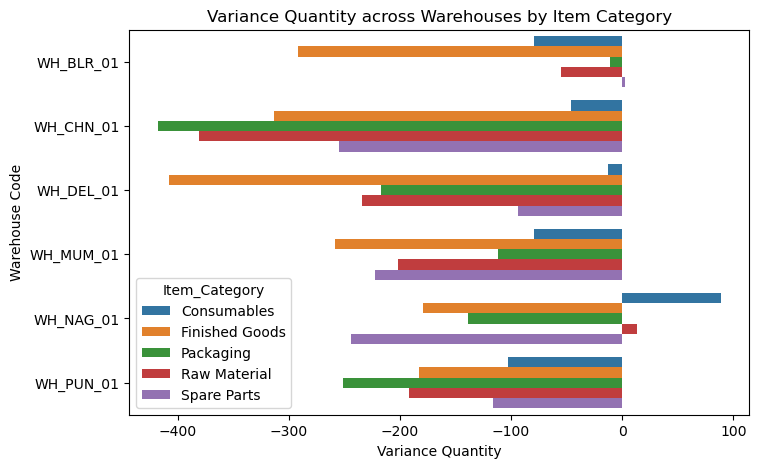

In [136]:
plt.figure(figsize=(8,5))
sns.barplot(
    data = merged_discrepancy_item.groupby(['Warehouse_Code_x','Item_Category'])['Variance_Quantity'].sum().reset_index(),
    x = 'Variance_Quantity', y = 'Warehouse_Code_x', hue = 'Item_Category'
)

plt.title('Variance Quantity across Warehouses by Item Category'),
plt.ylabel('Warehouse Code'),
plt.xlabel('Variance Quantity'),
        
plt.show()

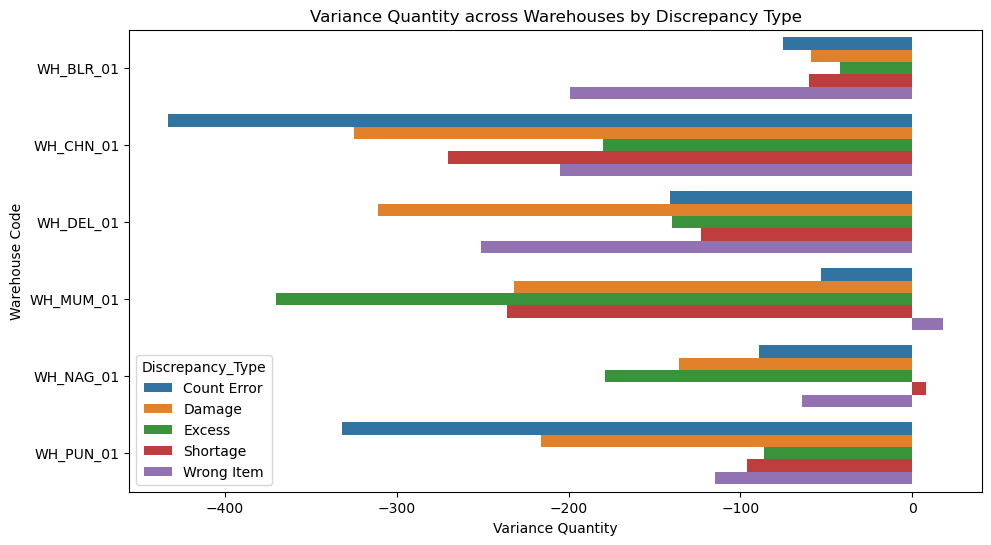

In [137]:
# which type of discrepancies are higher?

plt.figure(figsize=(11,6))
sns.barplot(
    data = merged_discrepancy_item.groupby(['Warehouse_Code_x','Discrepancy_Type'])['Variance_Quantity'].sum()\
        .reset_index(),
    x = 'Variance_Quantity', y = 'Warehouse_Code_x', hue = 'Discrepancy_Type'
)

plt.title('Variance Quantity across Warehouses by Discrepancy Type'),
plt.ylabel('Warehouse Code'),
plt.xlabel('Variance Quantity'),
        
plt.show()

In [138]:
# Is high movement causing high discrepancy?

inventory_movement.groupby('Warehouse_Code')['Movement_Quantity'].sum() \
    .reset_index() \
    .sort_values(by='Movement_Quantity', ascending=False)


,Warehouse_Code,Movement_Quantity
0,WH_BLR_01,396314
3,WH_MUM_01,394792
2,WH_DEL_01,393018
1,WH_CHN_01,390647
4,WH_NAG_01,389924
5,WH_PUN_01,388589


In [139]:
# Validation status by warehouse

merged_discrepancy_validation = pd.merge(discrepancy_log,inventory_validation,on='Movement_ID')


In [140]:
merged_discrepancy_validation.head(1)

,Discrepancy_ID,Movement_ID,Item_ID,Warehouse_Code,Discrepancy_Date,Expected_Quantity,Actual_Quantity,Variance_Quantity,Discrepancy_Type,Root_Cause,Resolution_Status,Validation_ID,Validation_Date,Validation_Rule,Validation_Status,Validator,Remarks,Year,Month
0,DISC6000000,MOV3000004,ITEM122157,WH_NAG_01,23-07-24,30,27,-3,Wrong Item,Documentation missing,Resolved,VAL7000000,2023-03-23,UOM consistency,Pass,auditor_suresh,NaN,2023,March


In [141]:
pd.crosstab(merged_discrepancy_validation['Warehouse_Code'], merged_discrepancy_validation['Validation_Status'])

Validation_Status,Fail,Pass
Warehouse_Code,,
WH_BLR_01,572,2080
WH_CHN_01,559,2039
WH_DEL_01,561,1992
WH_MUM_01,582,1922
WH_NAG_01,515,2045
WH_PUN_01,533,1936


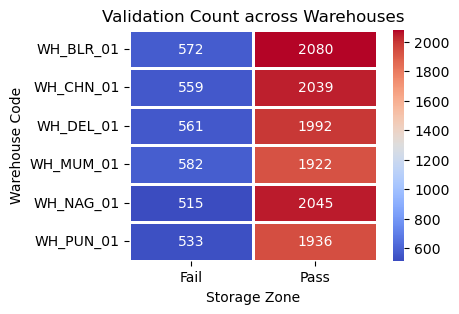

In [142]:
plt.figure(figsize=(4,3))

sns.heatmap(
    data = pd.crosstab(merged_discrepancy_validation['Warehouse_Code'],
                       merged_discrepancy_validation['Validation_Status']),
    annot = True, fmt = 'd', cmap ='coolwarm', linewidths= 0.9
)

plt.title('Validation Count across Warehouses'),
plt.ylabel('Warehouse Code'),
plt.xlabel('Storage Zone'),
        
plt.show()

In [143]:
# Identify how much discrepancies occured as compared to total movements

merged_discrepancy_kpi = pd.merge(discrepancy_log,inventory_kpi,on='Warehouse_Code')


In [144]:
merged_discrepancy_kpi.head(1)

,Discrepancy_ID,Movement_ID,Item_ID,Warehouse_Code,Discrepancy_Date,Expected_Quantity,Actual_Quantity,Variance_Quantity,Discrepancy_Type,Root_Cause,...,Outward_Movements,Total_Quantity_Moved,Mismatch_Count,Discrepancy_Count,Total_Variance,Validations_Done,Validation_Failures,Task_Completion_Rate_%,Mismatch_Rate_%,Validation_Failure_Rate_%
0,DISC6000000,MOV3000004,ITEM122157,WH_NAG_01,23-07-24,30,27,-3,Wrong Item,Documentation missing,...,216,8417,41,53,19,407,86,84.62,9.56,21.13


In [145]:
merged_discrepancy_kpi.groupby('Warehouse_Code')[['Total_Movements', 'Variance_Quantity']].sum()

,Total_Movements,Variance_Quantity
Warehouse_Code,,
WH_BLR_01,53928420,-20880
WH_CHN_01,51409224,-67824
WH_DEL_01,51042129,-46368
WH_MUM_01,50210208,-41904
WH_NAG_01,51543040,-22080
WH_PUN_01,48634362,-40560


In [146]:
result = merged_discrepancy_kpi.groupby('Warehouse_Code')[['Total_Movements', 'Variance_Quantity']].sum().reset_index()

In [147]:
result['Variance_%'] = (result['Variance_Quantity'] / result['Total_Movements']) * 100

print(result)

  Warehouse_Code  Total_Movements  Variance_Quantity  Variance_%
0      WH_BLR_01         53928420             -20880   -0.038718
1      WH_CHN_01         51409224             -67824   -0.131930
2      WH_DEL_01         51042129             -46368   -0.090843
3      WH_MUM_01         50210208             -41904   -0.083457
4      WH_NAG_01         51543040             -22080   -0.042838
5      WH_PUN_01         48634362             -40560   -0.083398


# 2nd Statement : Are incomplete tasks causing discrepancies?

In [156]:
merged_discrepancy_item_movement = pd.merge(
    merged_discrepancy_item, inventory_movement, on = 'Movement_ID'
)

In [157]:
merged_discrepancy_item_movement.rename(columns={'Warehouse_Code_x' : 'Warehouse_Code'},inplace=True)

In [158]:
merged_discrepancy_item_movement_task = pd.merge(
    merged_discrepancy_item_movement, task_allocation, on = 'Task_ID'
)

In [159]:
merged_discrepancy_item_movement_task.shape

(15336, 38)

In [161]:
merged_discrepancy_item_movement_task.columns

Index(['Discrepancy_ID', 'Movement_ID', 'Item_ID_x', 'Warehouse_Code_x',
       'Discrepancy_Date', 'Expected_Quantity', 'Actual_Quantity',
       'Variance_Quantity', 'Discrepancy_Type', 'Root_Cause',
       'Resolution_Status', 'Item_Description', 'Item_Category',
       'Priority_Level', 'UOM', 'Warehouse_Code_y', 'Warehouse_City',
       'Active_Flag', 'Movement_Date', 'Item_ID_y', 'Warehouse_Code_x',
       'Task_ID', 'Movement_Type', 'Movement_Quantity', 'Source',
       'Destination', 'Verification_Status', 'Year_x', 'Month_x', 'Task_Date',
       'Item_ID', 'Warehouse_Code_y', 'Task_Type', 'Assigned_Staff',
       'Assigned_Quantity', 'Task_Status', 'Year_y', 'Month_y'],
      dtype='object')

In [162]:
merged_discrepancy_item_movement_task.rename(columns={'Item_ID_x' : 'Item_ID'},inplace=True)

In [163]:
merged_discrepancy_item_movement_task.rename(columns={'Warehouse_Code_x' : 'Warehouse_Code'},inplace=True)

In [164]:
merged_discrepancy_item_movement_task.drop(
    columns=['Warehouse_Code'], inplace=True
)

In [165]:
merged_discrepancy_item_movement_task.groupby(['Warehouse_City','Task_Status'])['Variance_Quantity'].sum().reset_index()

,Warehouse_City,Task_Status,Variance_Quantity
0,Bangalore,Cancelled,-54
1,Bangalore,Completed,-405
2,Bangalore,Pending,24
3,Chennai,Cancelled,-113
4,Chennai,Completed,-1302
5,Chennai,Pending,2
6,Delhi,Cancelled,17
7,Delhi,Completed,-937
8,Delhi,Pending,-46
9,Mumbai,Cancelled,-47


Text(0, 0.5, 'Warehouse Code')

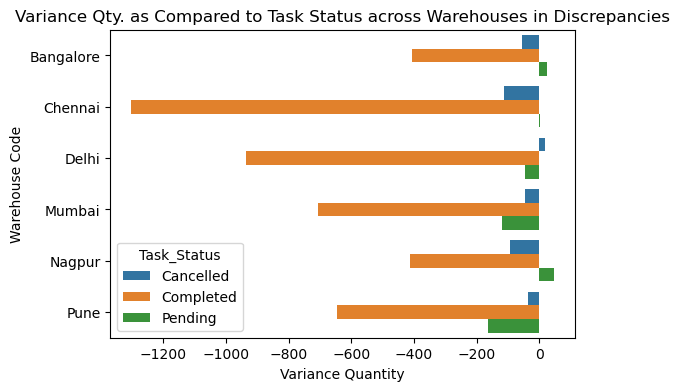

In [166]:
plt.figure(figsize=(6,4))

sns.barplot (
    data = merged_discrepancy_item_movement_task.groupby(['Warehouse_City','Task_Status'])['Variance_Quantity']\
        .sum().reset_index(),
    x = 'Variance_Quantity', y = 'Warehouse_City', hue = 'Task_Status'
)

plt.title('Variance Qty. as Compared to Task Status across Warehouses in Discrepancies')
plt.xlabel('Variance Quantity')
plt.ylabel('Warehouse Code')

In [167]:
merged_discrepancy_item_movement_task_validation = pd.merge(
    merged_discrepancy_item_movement_task, inventory_validation, on = 'Movement_ID'
)

In [168]:
merged_discrepancy_item_movement_task_validation.shape

(15336, 44)

In [169]:
merged_discrepancy_item_movement_task_validation.columns

Index(['Discrepancy_ID', 'Movement_ID', 'Item_ID', 'Discrepancy_Date',
       'Expected_Quantity', 'Actual_Quantity', 'Variance_Quantity',
       'Discrepancy_Type', 'Root_Cause', 'Resolution_Status',
       'Item_Description', 'Item_Category', 'Priority_Level', 'UOM',
       'Warehouse_Code_y', 'Warehouse_City', 'Active_Flag', 'Movement_Date',
       'Item_ID_y', 'Task_ID', 'Movement_Type', 'Movement_Quantity', 'Source',
       'Destination', 'Verification_Status', 'Year_x', 'Month_x', 'Task_Date',
       'Item_ID', 'Warehouse_Code_y', 'Task_Type', 'Assigned_Staff',
       'Assigned_Quantity', 'Task_Status', 'Year_y', 'Month_y',
       'Validation_ID', 'Validation_Date', 'Validation_Rule',
       'Validation_Status', 'Validator', 'Remarks', 'Year', 'Month'],
      dtype='object')

In [170]:
merged_discrepancy_item_movement_task_validation.groupby(['Warehouse_City'])

In [171]:
# Pending tasks + failed validation = dangerous combo

d = merged_discrepancy_item_movement_task_validation[
    (merged_discrepancy_item_movement_task_validation['Validation_Status'] == 'Fail') &
 (merged_discrepancy_item_movement_task_validation['Task_Status'] == 'Pending')
]

In [172]:
d.groupby('Discrepancy_Type')['Variance_Quantity'].sum()

Discrepancy_Type
Count Error    57
Damage         46
Excess          2
Shortage       69
Wrong Item    -59
Name: Variance_Quantity, dtype: int64

Text(0, 0.5, 'Discrepancy Type')

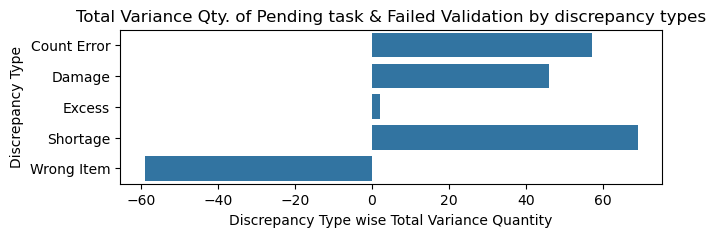

In [173]:
plt.figure(figsize=(7,2))

sns.barplot(
    data = d.groupby('Discrepancy_Type')['Variance_Quantity'].sum().reset_index(),
    x = 'Variance_Quantity', y = 'Discrepancy_Type',
)

plt.title('Total Variance Qty. of Pending task & Failed Validation by discrepancy types')
plt.xlabel('Discrepancy Type wise Total Variance Quantity')
plt.ylabel('Discrepancy Type')

In [174]:
d.groupby(['Warehouse_City','Discrepancy_Type'])['Variance_Quantity'].sum().reset_index()

,Warehouse_City,Discrepancy_Type,Variance_Quantity
0,Bangalore,Count Error,24
1,Bangalore,Damage,4
2,Bangalore,Excess,-7
3,Bangalore,Shortage,15
4,Bangalore,Wrong Item,22
5,Chennai,Count Error,-14
6,Chennai,Damage,28
7,Chennai,Excess,-21
8,Chennai,Shortage,-6
9,Chennai,Wrong Item,-8


Text(0, 0.5, 'Warehouse Code')

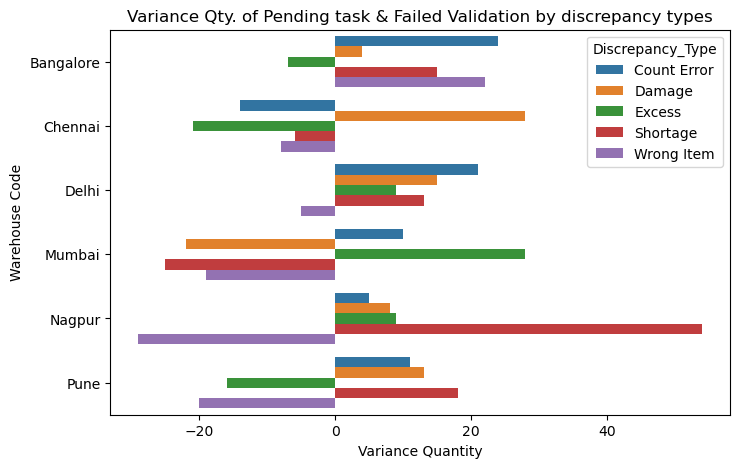

In [175]:
plt.figure(figsize=(8,5))
sns.barplot(
    data = d.groupby(['Warehouse_City','Discrepancy_Type'])['Variance_Quantity'].sum().reset_index(),
    x = 'Variance_Quantity', y = 'Warehouse_City', hue = 'Discrepancy_Type'
)

plt.title('Variance Qty. of Pending task & Failed Validation by discrepancy types')
plt.xlabel('Variance Quantity')
plt.ylabel('Warehouse Code')

# 3rd Statement : Are high-movement items more likely to create discrepancies?
# Which items are high-risk and need special monitoring?

In [176]:
merged_discrepancy_item_movement_task_validation.head(1)

,Discrepancy_ID,Movement_ID,Item_ID,Discrepancy_Date,Expected_Quantity,Actual_Quantity,Variance_Quantity,Discrepancy_Type,Root_Cause,Resolution_Status,...,Year_y,Month_y,Validation_ID,Validation_Date,Validation_Rule,Validation_Status,Validator,Remarks,Year,Month
0,DISC6000000,MOV3000004,ITEM122157,23-07-24,30,27,-3,Wrong Item,Documentation missing,Resolved,...,2024,June,VAL7000000,2023-03-23,UOM consistency,Pass,auditor_suresh,NaN,2023,March


In [177]:
merged_discrepancy_item_movement_task_validation.groupby(['Warehouse_City','Item_Category'])\
['Movement_Quantity'].sum().reset_index()

,Warehouse_City,Item_Category,Movement_Quantity
0,Bangalore,Consumables,5143
1,Bangalore,Finished Goods,17052
2,Bangalore,Packaging,9163
3,Bangalore,Raw Material,14208
4,Bangalore,Spare Parts,6254
5,Chennai,Consumables,5699
6,Chennai,Finished Goods,16346
7,Chennai,Packaging,8859
8,Chennai,Raw Material,14648
9,Chennai,Spare Parts,6088


Text(0, 0.5, 'Warehouse City')

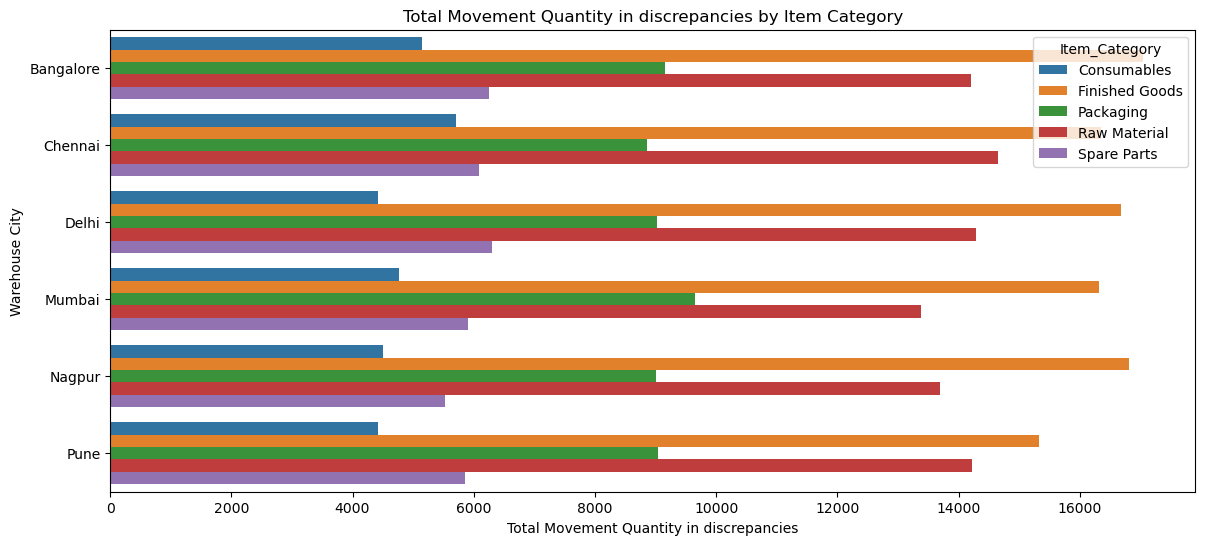

In [178]:
plt.figure(figsize=(14,6))

sns.barplot(
    data = merged_discrepancy_item_movement_task_validation.groupby(['Warehouse_City','Item_Category'])\
['Movement_Quantity'].sum().reset_index(),
    x = 'Movement_Quantity', y = 'Warehouse_City', hue = 'Item_Category'
)

plt.title('Total Movement Quantity in discrepancies by Item Category')
plt.xlabel('Total Movement Quantity in discrepancies')
plt.ylabel('Warehouse City')

In [179]:
merged_discrepancy_item_movement_task_validation.groupby(['Warehouse_City','Priority_Level'])\
['Movement_Quantity'].sum().reset_index()

,Warehouse_City,Priority_Level,Movement_Quantity
0,Bangalore,High,21593
1,Bangalore,Low,6898
2,Bangalore,Medium,23329
3,Chennai,High,23468
4,Chennai,Low,5831
5,Chennai,Medium,22341
6,Delhi,High,22452
7,Delhi,Low,5920
8,Delhi,Medium,22361
9,Mumbai,High,24000


Text(0, 0.5, 'Warehouse City')

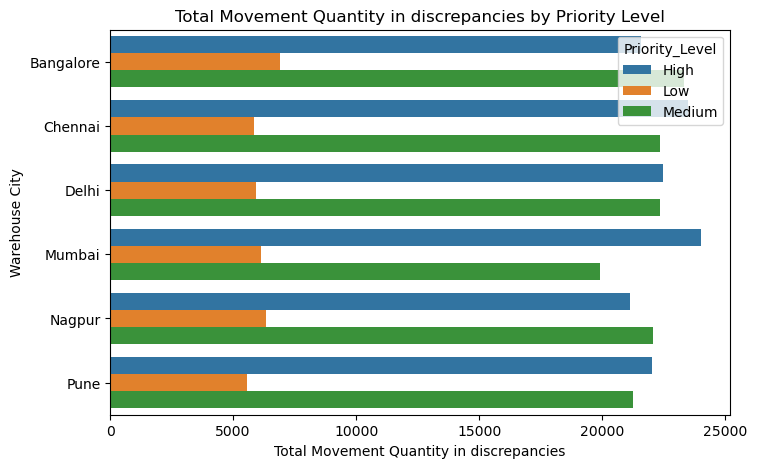

In [180]:
plt.figure(figsize=(8,5))

sns.barplot(
    data = merged_discrepancy_item_movement_task_validation.groupby(['Warehouse_City','Priority_Level'])\
['Movement_Quantity'].sum().reset_index(),
    x = 'Movement_Quantity', y = 'Warehouse_City', hue = 'Priority_Level'
)

plt.title('Total Movement Quantity in discrepancies by Priority Level')
plt.xlabel('Total Movement Quantity in discrepancies')
plt.ylabel('Warehouse City')

Text(0, 0.5, 'Warehouse City')

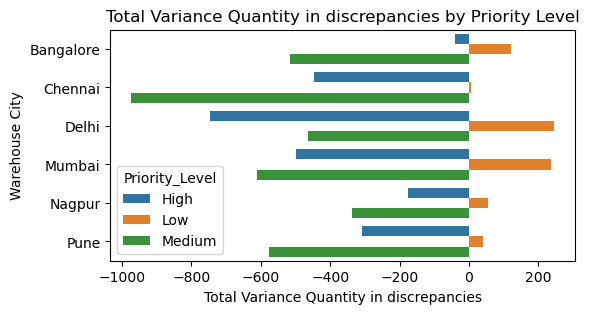

In [181]:
plt.figure(figsize=(6,3))

sns.barplot(
    data = merged_discrepancy_item_movement_task_validation.groupby(['Warehouse_City','Priority_Level'])\
['Variance_Quantity'].sum().reset_index(),
    x = 'Variance_Quantity', y = 'Warehouse_City', hue = 'Priority_Level'
)

plt.title('Total Variance Quantity in discrepancies by Priority Level')
plt.xlabel('Total Variance Quantity in discrepancies')
plt.ylabel('Warehouse City')

Text(0, 0.5, 'Warehouse City')

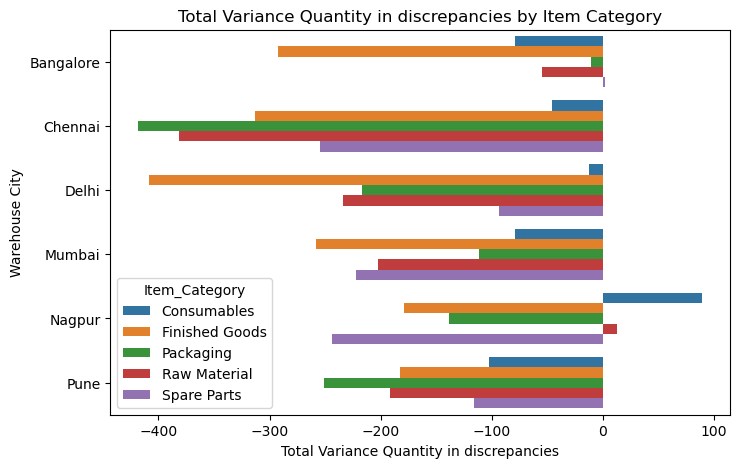

In [182]:
plt.figure(figsize=(8,5))

sns.barplot(
    data = merged_discrepancy_item_movement_task_validation.groupby(['Warehouse_City','Item_Category'])\
['Variance_Quantity'].sum().reset_index(),
    x = 'Variance_Quantity', y = 'Warehouse_City', hue = 'Item_Category'
)

plt.title('Total Variance Quantity in discrepancies by Item Category')
plt.xlabel('Total Variance Quantity in discrepancies')
plt.ylabel('Warehouse City')

# 4th Statement : Are some warehouses handling too much work?

<Axes: ylabel='Movement_Quantity'>

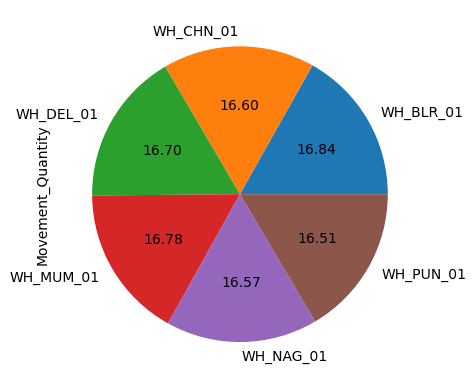

In [183]:
inventory_movement.groupby('Warehouse_Code')['MovemenDt_Quantity'].sum().plot(kind='pie',autopct='%.02f')

<Axes: ylabel='Assigned_Quantity'>

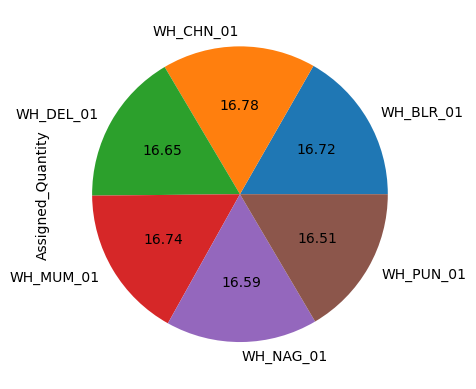

In [184]:
task_allocation.groupby('Warehouse_Code')['Assigned_Quantity'].sum().plot(kind='pie',autopct='%.02f')

# 5th Statement : Are some Staff handling too much work?

In [185]:
task_allocation.groupby(['Warehouse_Code', 'Assigned_Staff'])['Assigned_Quantity'].sum().reset_index()

,Warehouse_Code,Assigned_Staff,Assigned_Quantity
0,WH_BLR_01,staff_ajay,59776
1,WH_BLR_01,staff_amit,41675
2,WH_BLR_01,staff_kiran,33926
3,WH_BLR_01,staff_priya,41470
4,WH_BLR_01,staff_rohit,49436
5,WH_BLR_01,staff_sneha,46838
6,WH_BLR_01,staff_sonal,34084
7,WH_BLR_01,staff_vikas,29828
8,WH_CHN_01,staff_ajay,60456
9,WH_CHN_01,staff_amit,40843


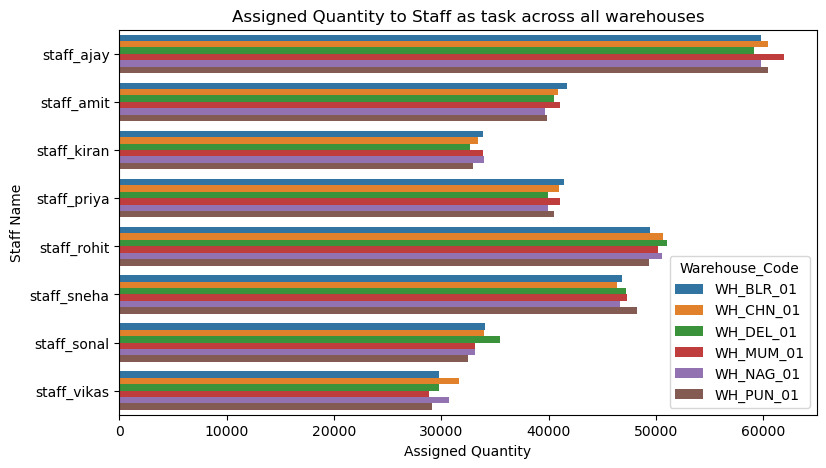

In [186]:
plt.figure(figsize=(9,5))

sns.barplot(
    data = task_allocation.groupby(['Warehouse_Code', 'Assigned_Staff'])['Assigned_Quantity'].sum().reset_index(),
    x = 'Assigned_Quantity',
    y = 'Assigned_Staff',
    hue = 'Warehouse_Code'
)

plt.title('Assigned Quantity to Staff as task across all warehouses')
plt.xlabel ('Assigned Quantity')
plt.ylabel ('Staff Name')
plt.show()

In [187]:
merged_task_item = pd.merge(
    task_allocation, inventory_item, on = 'Item_ID'
)

In [188]:
merged_task_item_movement = pd. merge (
    merged_task_item, inventory_movement, on = 'Item_ID'
)

In [189]:
merged_task_item_movement.shape

(419887, 28)

In [190]:
merged_task_item_movement.groupby(['Warehouse_City','Assigned_Staff'])['Movement_Quantity'].sum().reset_index()

,Warehouse_City,Assigned_Staff,Movement_Quantity
0,Bangalore,staff_ajay,255380
1,Bangalore,staff_amit,169707
2,Bangalore,staff_kiran,142950
3,Bangalore,staff_priya,167432
4,Bangalore,staff_rohit,206732
5,Bangalore,staff_sneha,193634
6,Bangalore,staff_sonal,139065
7,Bangalore,staff_vikas,120462
8,Chennai,staff_ajay,248439
9,Chennai,staff_amit,167459


Text(0, 0.5, 'Name of Staff')

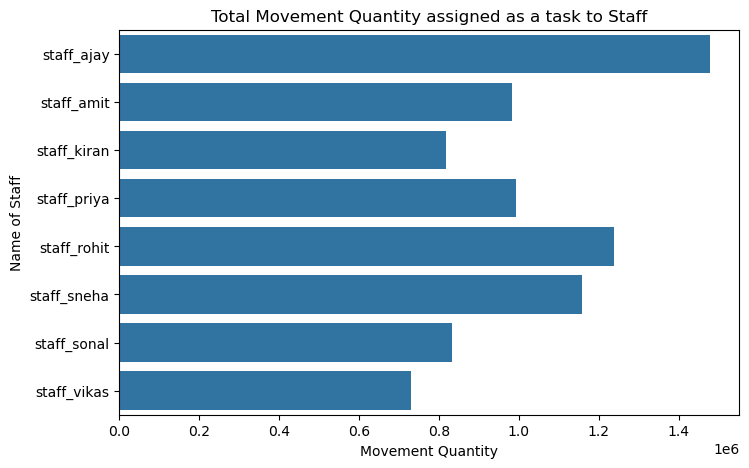

In [191]:
plt.figure(figsize=(8,5))
sns.barplot(
    data = merged_task_item_movement.groupby('Assigned_Staff')['Movement_Quantity'].sum().reset_index(),
    x = 'Movement_Quantity', 
    y = 'Assigned_Staff',
)

plt.title('Total Movement Quantity assigned as a task to Staff')
plt.xlabel('Movement Quantity')
plt.ylabel('Name of Staff')

# Key Business Insights

- Analysed relationships among multiple variables.
- Identified important feature interactions.
- Evaluated correlation patterns across the dataset.
- Generated insights useful for operational and strategic decision-making.

# Conclusion

Multivariate Analysis provides a deeper understanding of how multiple variables interact and helps uncover complex patterns that are not visible through univariate or bivariate analysis alone.